# FRED

**Research Question:** How does stress in the non-financial commercial paper market influence firms' working capital management and supply-chain operations?

**Scope:** Raw data acquisition from the FRED API covering commercial paper rates, volumes, and maturity structure. Series are aligned to a weekly Wednesday index and used to construct the Composite Stress Index (CSI) that underpins the empirical analysis across all notebooks.

**Output:** The cleaned and aligned weekly series are saved to `data/raw/` as `FR_<series_id>.csv` and feed directly into the Composite Stress Index (CSI) construction in Section 6, which is used as the primary stress measure across all downstream notebooks.

## Section 1 – Imports & Configuration

In [31]:
# Imports
import warnings
warnings.filterwarnings("ignore", category=Warning, module="urllib3")

# Core Data & API
import requests
import pandas as pd

# File system & config
from dotenv import load_dotenv
import os
import json
import sys
from pathlib import Path


# Time handling
from datetime import datetime, date
import time

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

# Analysis
import numpy as np
import scipy.stats as stats
from sklearn.decomposition import PCA

# Configuration

sys.path.insert(0, str(Path().resolve().parent))
from config import *
load_dotenv(ANALYSIS_DIR / ".env")
FRED_API_KEY = os.getenv("FRED_API_KEY")
assert FRED_API_KEY, "FRED_API_KEY not found — check your .env file"

FRED_BASE_URL = "https://api.stlouisfed.org/fred"


## Section 2 – FRED API Helper Functions

In [32]:
def fred_get(endpoint: str, params: dict) -> dict:
    """Base GET request to the FRED API. Returns parsed JSON."""
    params = {**params, "api_key": FRED_API_KEY, "file_type": "json"}
    response = requests.get(f"{FRED_BASE_URL}/{endpoint}", params=params)
    response.raise_for_status()
    return response.json()


def get_series_info(series_id: str) -> dict:
    """Fetch metadata for a single series (name, frequency, units, etc.)."""
    data = fred_get("series", {"series_id": series_id})
    return data["seriess"][0]


def get_series_data(
    series_id: str,
    start_date: str = "2000-01-01",
    end_date: str = None,
) -> pd.DataFrame:
    """
    Download observations for a series. Returns a cleaned DataFrame
    with a DatetimeIndex and a single column named after the series_id.
    """
    params = {"series_id": series_id, "observation_start": start_date}
    if end_date:
        params["observation_end"] = end_date

    data = fred_get("series/observations", params)
    df = pd.DataFrame(data["observations"])[["date", "value"]]
    df["date"]  = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")  # "." → NaN
    df = df.rename(columns={"value": series_id}).set_index("date")
    return df


def save_series(df: pd.DataFrame, series_id: str) -> Path:
    """Save a series DataFrame to data/<series_id>.csv."""
    path = RAW_DIR / f"FR_{series_id}.csv"
    df.to_csv(path)
    print(f"  ✓ Saved {series_id} → {path}")
    return path


def load_series(series_id: str) -> pd.DataFrame:
    """Load a previously saved series from data/<series_id>.csv."""
    path = RAW_DIR / f"FR_{series_id}.csv"
    return pd.read_csv(path, index_col="date", parse_dates=True)

def shade_recessions(ax, rec_series):
    """Shade NBER recession periods on a matplotlib axis.
    rec_series: a 0/1 pandas Series on any frequency, reindexed to the plot index."""
    in_rec = False
    start  = None
    for date, val in rec_series.items():
        if val == 1 and not in_rec:
            in_rec = True
            start  = date
        elif val == 0 and in_rec:
            in_rec = False
            ax.axvspan(start, date, color="lightgrey", alpha=0.5, zorder=0)
    if in_rec:
        ax.axvspan(start, rec_series.index[-1], color="lightgrey", alpha=0.5, zorder=0)

## Section 3 – Data Acquisition

In [33]:
START_DATE = "2000-01-01"

SERIES_IDS = {

    # ── NF CP Rates — AA (daily) ──────────────────────────────────────────────
    "RIFSPPNAAD01NB":  "NF CP AA Overnight",
    "RIFSPPNAAD07NB":  "NF CP AA 7-day",
    "RIFSPPNAAD30NB":  "NF CP AA 30-day",
    "DCPN2M":          "NF CP AA 60-day",
    "DCPN3M":          "NF CP AA 90-day",

    # ── NF CP Rates — A2/P2 (daily) ──────────────────────────────────────────
    "RIFSPPNA2P2D01NB": "NF CP A2/P2 Overnight",
    "RIFSPPNA2P2D07NB": "NF CP A2/P2 7-day",
    "RIFSPPNA2P2D30NB": "NF CP A2/P2 30-day",
    "RIFSPPNA2P2D60NB": "NF CP A2/P2 60-day",
    "RIFSPPNA2P2D90NB": "NF CP A2/P2 90-day",

    # ── ABCP Rates — AA (daily) ───────────────────────────────────────────────
    "RIFSPPAAAD01NB":  "ABCP AA Overnight",
    "RIFSPPAAAD07NB":  "ABCP AA 7-day",
    "RIFSPPAAAD30NB":  "ABCP AA 30-day",
    "RIFSPPAAAD60NB":  "ABCP AA 60-day",
    "RIFSPPAAAD90NB":  "ABCP AA 90-day",

    # ── NF CP Outstanding Volume (weekly) ────────────────────────────────────
    "COMPAPER":        "NF CP Total Outstanding",
    "DNFINCPN":        "NF CP Domestic Outstanding",
    "FNFINCPN":        "NF CP Foreign Outstanding",
    "DTBSPCKNONWW":    "NF CP Other Outstanding",
    "ABCOMPN":         "ABCP Total Outstanding",

    # ── NF CP AA — Issue Amount by Maturity Bucket (daily) ───────────────────
    "NONFIN14AAAMT":   "NF CP AA Amount 1-4 days",
    "NONFIN59AAAMT":   "NF CP AA Amount 5-9 days",
    "NONFIN1020AAAMT": "NF CP AA Amount 10-20 days",
    "NONFIN2140AAAMT": "NF CP AA Amount 21-40 days",
    "NONFIN4180AAAMT": "NF CP AA Amount 41-80 days",
    "NONFINGT80AAAMT": "NF CP AA Amount >80 days",

    # ── NF CP AA — Issue Count by Maturity Bucket (daily) ────────────────────
    "NONFIN14AAVOL":   "NF CP AA Count 1-4 days",
    "NONFIN59AAVOL":   "NF CP AA Count 5-9 days",
    "NONFIN1020AAVOL": "NF CP AA Count 10-20 days",
    "NONFIN2140AAVOL": "NF CP AA Count 21-40 days",
    "NONFIN4180AAVOL": "NF CP AA Count 41-80 days",
    "NONFINGT80AAVOL": "NF CP AA Count >80 days",

    # ── NF CP A2/P2 — Issue Amount by Maturity Bucket (daily) ────────────────
    "NONFIN14A2P2AMT":   "NF CP A2/P2 Amount 1-4 days",
    "NONFIN59A2P2AMT":   "NF CP A2/P2 Amount 5-9 days",
    "NONFIN1020A2P2AMT": "NF CP A2/P2 Amount 10-20 days",
    "NONFIN2140A2P2AMT": "NF CP A2/P2 Amount 21-40 days",
    "NONFIN4180A2P2AMT": "NF CP A2/P2 Amount 41-80 days",
    "NONFINGT80A2P2AMT": "NF CP A2/P2 Amount >80 days",

    # ── NF CP A2/P2 — Issue Count by Maturity Bucket (daily) ─────────────────
    "NONFIN14A2P2VOL":   "NF CP A2/P2 Count 1-4 days",
    "NONFIN59A2P2VOL":   "NF CP A2/P2 Count 5-9 days",
    "NONFIN1020A2P2VOL": "NF CP A2/P2 Count 10-20 days",
    "NONFIN2140A2P2VOL": "NF CP A2/P2 Count 21-40 days",
    "NONFIN4180A2P2VOL": "NF CP A2/P2 Count 41-80 days",
    "NONFINGT80A2P2VOL": "NF CP A2/P2 Count >80 days",

    # ── ABCP AA — Issue Amount by Maturity Bucket (daily) ────────────────────
    "AB14AAAMT":   "ABCP AA Amount 1-4 days",
    "AB59AAAMT":   "ABCP AA Amount 5-9 days",
    "AB1020AAAMT": "ABCP AA Amount 10-20 days",
    "AB2140AAAMT": "ABCP AA Amount 21-40 days",
    "AB4180AAAMT": "ABCP AA Amount 41-80 days",
    "ABGT80AAAMT": "ABCP AA Amount >80 days",

    # ── ABCP AA — Issue Count by Maturity Bucket (daily) ─────────────────────
    "AB14AAVOL":   "ABCP AA Count 1-4 days",
    "AB59AAVOL":   "ABCP AA Count 5-9 days",
    "AB1020AAVOL": "ABCP AA Count 10-20 days",
    "AB2140AAVOL": "ABCP AA Count 21-40 days",
    "AB4180AAVOL": "ABCP AA Count 41-80 days",
    "ABGT80AAVOL": "ABCP AA Count >80 days",

    # ── Risk-Free & Macro Reference (daily) ──────────────────────────────────
    "DGS1MO":  "T-Bill 1-month",
    "DGS3MO":  "T-Bill 3-month",
    "DGS1":    "T-Bill 1-year",
    "DFF":     "Federal Funds Effective Rate",
    "SOFR":    "SOFR",
    "IORB":    "Interest on Reserve Balances",
    "VIXCLS":  "VIX",

    # ── Recession Indicator (monthly) ────────────────────────────────────────
    "USREC":   "NBER Recession Indicator",
}

# ── Download loop ─────────────────────────────────────────────────────────────
failed = []

for series_id, description in SERIES_IDS.items():
    try:
        print(f"Fetching {series_id}: {description}...")
        df = get_series_data(series_id, start_date=START_DATE)
        save_series(df, series_id)
        time.sleep(0.5)
    except Exception as e:
        print(f"  [!] FAILED {series_id}: {e}")
        failed.append((series_id, description, str(e)))

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'─'*60}")
print(f"  Downloaded: {len(SERIES_IDS) - len(failed)}/{len(SERIES_IDS)} series")
if failed:
    print(f"  Failed ({len(failed)}):")
    for sid, desc, err in failed:
        print(f"    {sid} ({desc}): {err}")
else:
    print("  All series downloaded successfully.")
print(f"{'─'*60}")

Fetching RIFSPPNAAD01NB: NF CP AA Overnight...
  ✓ Saved RIFSPPNAAD01NB → /Users/leo/Desktop/Thesis/Analysis/data/raw/FR_RIFSPPNAAD01NB.csv
Fetching RIFSPPNAAD07NB: NF CP AA 7-day...
  ✓ Saved RIFSPPNAAD07NB → /Users/leo/Desktop/Thesis/Analysis/data/raw/FR_RIFSPPNAAD07NB.csv
Fetching RIFSPPNAAD30NB: NF CP AA 30-day...
  ✓ Saved RIFSPPNAAD30NB → /Users/leo/Desktop/Thesis/Analysis/data/raw/FR_RIFSPPNAAD30NB.csv
Fetching DCPN2M: NF CP AA 60-day...
  ✓ Saved DCPN2M → /Users/leo/Desktop/Thesis/Analysis/data/raw/FR_DCPN2M.csv
Fetching DCPN3M: NF CP AA 90-day...
  ✓ Saved DCPN3M → /Users/leo/Desktop/Thesis/Analysis/data/raw/FR_DCPN3M.csv
Fetching RIFSPPNA2P2D01NB: NF CP A2/P2 Overnight...
  ✓ Saved RIFSPPNA2P2D01NB → /Users/leo/Desktop/Thesis/Analysis/data/raw/FR_RIFSPPNA2P2D01NB.csv
Fetching RIFSPPNA2P2D07NB: NF CP A2/P2 7-day...
  ✓ Saved RIFSPPNA2P2D07NB → /Users/leo/Desktop/Thesis/Analysis/data/raw/FR_RIFSPPNA2P2D07NB.csv
Fetching RIFSPPNA2P2D30NB: NF CP A2/P2 30-day...
  ✓ Saved RIFSPPNA

## Section 4 – Data Inventory / Validation

In [34]:
# CELL 4.1 — Build inventory table
 
inventory_rows = []
 
for series_id, description in SERIES_IDS.items():
 
    row = {
        "series_id":   series_id,
        "description": description,
        "first_date":  pd.NaT,
        "last_date":   pd.NaT,
        "n_obs":       pd.NA,
        "n_nan":       pd.NA,
        "pct_nan":     pd.NA,
        "inferred_freq": "unknown",
        "units":       "unknown",
        "api_note":    "",
    }
 
    # --- load CSV -----------------------------------------------------------
    try:
        df = load_series(series_id)
    except FileNotFoundError:
        row["api_note"] = "CSV missing — re-run Section 3"
        inventory_rows.append(row)
        print(f"  [MISSING CSV]  {series_id}")
        continue
 
    # --- basic stats --------------------------------------------------------
    col = df[series_id]
    row["first_date"] = col.index.min()
    row["last_date"]  = col.index.max()
    row["n_obs"]      = len(col)
    row["n_nan"]      = int(col.isna().sum())
    row["pct_nan"]    = round(100 * row["n_nan"] / row["n_obs"], 1) if row["n_obs"] else pd.NA
 
    # --- infer frequency from median gap ------------------------------------
    if len(col.dropna()) >= 2:
        gaps = col.dropna().index.to_series().diff().dt.days.dropna()
        median_gap = gaps.median()
        if median_gap <= 1.5:
            row["inferred_freq"] = "daily"
        elif median_gap <= 4:
            row["inferred_freq"] = "business-daily"
        elif median_gap <= 8:
            row["inferred_freq"] = "weekly"
        elif median_gap <= 16:
            row["inferred_freq"] = "bi-weekly"
        else:
            row["inferred_freq"] = "monthly+"
    else:
        row["inferred_freq"] = "insufficient data"
 
    # --- fetch metadata (units) from FRED API --------------------------------
    try:
        info = get_series_info(series_id)
        row["units"] = info.get("units_short", info.get("units", "unknown"))
        time.sleep(0.5)
    except Exception as e:
        row["units"]    = "API error"
        row["api_note"] = str(e)[:80]
        print(f"  [API WARNING]  {series_id}: {e}")
 
    inventory_rows.append(row)
 
inventory_df = pd.DataFrame(inventory_rows).set_index("series_id")
 
# Tidy date columns
inventory_df["first_date"] = pd.to_datetime(inventory_df["first_date"]).dt.date
inventory_df["last_date"]  = pd.to_datetime(inventory_df["last_date"]).dt.date
 
print(f"\nInventory complete: {len(inventory_df)} series processed.")
issues = inventory_df[inventory_df["api_note"] != ""]
if len(issues):
    print(f"  [!] {len(issues)} series with warnings — see 'api_note' column.")
else:
    print("  [✓] No warnings.")


Inventory complete: 64 series processed.
  [✓] No warnings.


In [35]:
# CELL 4.2 — Styled display

display_cols = [
    "description", "first_date", "last_date",
    "n_obs", "n_nan", "pct_nan", "inferred_freq", "units", "api_note",
]

def _color_nan(val):
    try:
        v = float(str(val).replace("%", ""))
        if v >= 20:
            return "background-color: rgba(220, 60, 60, 0.25) !important; color: #f4a0a0"
        elif v >= 10:
            return "background-color: rgba(220, 160, 40, 0.25) !important; color: #f0c070"
        else:
            return ""
    except (TypeError, ValueError):
        return ""

def _color_note(val):
    return "background-color: rgba(220, 60, 60, 0.25) !important; color: #f4a0a0" if val else ""

styled = (
    inventory_df[display_cols]
    .style
    .set_caption("Section 4 — Series inventory & completeness check")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "13px"), ("font-weight", "500"),
                   ("text-align", "left"), ("padding-bottom", "8px"),
                   ("border-bottom", "2px solid #3d3d3d")]},
        {"selector": "thead tr",
         "props": [("border-bottom", "2px solid #3d3d3d")]},
        {"selector": "th",
         "props": [("font-size", "11px"), ("font-weight", "500"),
                   ("letter-spacing", "0.04em"), ("text-transform", "uppercase"),
                   ("color", "#666"), ("background", "transparent"),
                   ("padding", "7px 10px"), ("text-align", "left")]},
        {"selector": "td",
         "props": [("font-size", "12px"), ("padding", "6px 10px")]},
        {"selector": "tr",
         "props": [("border-bottom", "0.5px solid #e0e0e0")]},
    ])
    .map(_color_nan, subset=["pct_nan"])
    .map(_color_note, subset=["api_note"])
    .format({
        "pct_nan": lambda x: f"{x:.1f}%" if pd.notna(x) else "—",
        "n_obs":   lambda x: f"{int(x):,}" if pd.notna(x) else "—",
        "n_nan":   lambda x: f"{int(x):,}" if pd.notna(x) else "—",
    })
)

display(styled)

,description,first_date,last_date,n_obs,n_nan,pct_nan,inferred_freq,units,api_note
series_id,,,,,,,,,
RIFSPPNAAD01NB,NF CP AA Overnight,2000-01-03,2026-06-09,"6,897",315,4.6%,daily,%,
RIFSPPNAAD07NB,NF CP AA 7-day,2000-01-03,2026-06-08,"6,896",807,11.7%,daily,%,
RIFSPPNAAD30NB,NF CP AA 30-day,2000-01-03,2026-06-09,"6,897",722,10.5%,daily,%,
DCPN2M,NF CP AA 60-day,2000-01-03,2026-06-09,"6,897","1,493",21.6%,daily,%,
DCPN3M,NF CP AA 90-day,2000-01-03,2026-06-09,"6,897","2,368",34.3%,daily,%,
RIFSPPNA2P2D01NB,NF CP A2/P2 Overnight,2000-01-03,2026-06-09,"6,897",287,4.2%,daily,%,
RIFSPPNA2P2D07NB,NF CP A2/P2 7-day,2000-01-03,2026-06-09,"6,897",300,4.3%,daily,%,
RIFSPPNA2P2D30NB,NF CP A2/P2 30-day,2000-01-03,2026-06-09,"6,897",313,4.5%,daily,%,
RIFSPPNA2P2D60NB,NF CP A2/P2 60-day,2000-01-03,2026-06-09,"6,897",834,12.1%,daily,%,


In [36]:
# CELL 4.3 — Gap-analysis commentary (auto-generated)
 
# Summaries used in the commentary
total       = len(inventory_df)
n_missing   = inventory_df["api_note"].str.contains("CSV missing").sum()
n_api_err   = inventory_df["api_note"].str.contains("API error").sum()
high_nan    = inventory_df[inventory_df["pct_nan"] >= 20]["pct_nan"].sort_values(ascending=False)
amber_nan   = inventory_df[(inventory_df["pct_nan"] >= 5) & (inventory_df["pct_nan"] < 20)]["pct_nan"].sort_values(ascending=False)
 
freq_counts = inventory_df["inferred_freq"].value_counts()
 
daily_series  = inventory_df[inventory_df["inferred_freq"].isin(["daily", "business-daily"])]
weekly_series = inventory_df[inventory_df["inferred_freq"] == "weekly"]
 
# Date-range diagnostics
earliest = inventory_df["first_date"].dropna().min()
latest   = inventory_df["last_date"].dropna().max()
short_start = inventory_df[
    pd.to_datetime(inventory_df["first_date"]) > pd.Timestamp("2005-01-01")
].sort_values("first_date")
 
print("=" * 70)
print("SECTION 4 — GAP-ANALYSIS COMMENTARY")
print("=" * 70)
 
print(f"\nOVERVIEW")
print(f"   {total} series inventoried in total.")
if n_missing:
    print(f"   [!] {n_missing} CSV(s) missing — Section 4 download may be incomplete.")
if n_api_err:
    print(f"   [!] {n_api_err} series returned API errors when fetching metadata (units shown as 'API error').")
print(f"   Full sample window: {earliest} -> {latest}")
 
print(f"\nFREQUENCY BREAKDOWN")
for freq, count in freq_counts.items():
    print(f"   {freq:<22} {count:>3} series")

 
print(f"\nHIGH NaN SERIES (>=20%)")
if len(high_nan):
    for sid, pct in high_nan.items():
        desc = inventory_df.loc[sid, "description"]
        first = inventory_df.loc[sid, "first_date"]
        last  = inventory_df.loc[sid, "last_date"]
        print(f"   {sid:<30} {pct:>5.1f}%  [{first} -> {last}]  {desc}")
else:
    print(f"   None — all series are >=80% complete. [✓]")
 
print(f"\nAMBER NaN SERIES (5-20%)")
if len(amber_nan):
    for sid, pct in amber_nan.items():
        desc = inventory_df.loc[sid, "description"]
        first = inventory_df.loc[sid, "first_date"]
        last  = inventory_df.loc[sid, "last_date"]
        print(f"   {sid:<30} {pct:>5.1f}%  [{first} -> {last}]  {desc}")
else:
    print(f"   None. [✓]")
 
print(f"\nSERIES WITH LATE START DATES (after 2005-01-01)")
if len(short_start):
    for sid, row in short_start.iterrows():
        print(f"   {sid:<30} starts {row['first_date']}  — {row['description']}")
else:
    print(f"   All series start on or before 2005-01-01. [✓]")
 
print("=" * 70)

SECTION 4 — GAP-ANALYSIS COMMENTARY

OVERVIEW
   64 series inventoried in total.
   Full sample window: 2000-01-01 -> 2026-06-11

FREQUENCY BREAKDOWN
   daily                   58 series
   weekly                   5 series
   monthly+                 1 series

HIGH NaN SERIES (>=20%)
   DCPN3M                          34.3%  [2000-01-03 -> 2026-06-09]  NF CP AA 90-day
   RIFSPPNA2P2D90NB                33.9%  [2000-01-03 -> 2026-06-05]  NF CP A2/P2 90-day
   DCPN2M                          21.6%  [2000-01-03 -> 2026-06-09]  NF CP AA 60-day

AMBER NaN SERIES (5-20%)
   RIFSPPNA2P2D60NB                12.1%  [2000-01-03 -> 2026-06-09]  NF CP A2/P2 60-day
   RIFSPPNAAD07NB                  11.7%  [2000-01-03 -> 2026-06-08]  NF CP AA 7-day
   RIFSPPNAAD30NB                  10.5%  [2000-01-03 -> 2026-06-09]  NF CP AA 30-day

SERIES WITH LATE START DATES (after 2005-01-01)
   SOFR                           starts 2018-04-03  — SOFR
   IORB                           starts 2021-07-29  — Int

## Section 5 – Data Alignment

All series are aligned to a weekly Wednesday index. Weekly frequency is preferred over
daily for three reasons: <br><br>(i) the downstream firm-level variables this analysis connects
to are reported at quarterly or monthly frequency, making daily granularity analytically
redundant; <br><br>(ii) weekly aggregation removes day-of-week patterns in CP
issuance without sacrificing resolution over the stress episodes of interest, which
unfolded over weeks and months; <br><br>(iii) the outstanding volume series (COMPAPER group)
are natively published on a Wednesday-week basis, so no resampling is required and rates
and quantities are observed on a consistent same-day basis throughout the sample.

In [37]:
# CELL 5.1 — Build the weekly Wednesday index and align all series

# Determine sample end from latest observation across all downloaded CSVs
end_date = pd.Timestamp("1900-01-01")
for series_id in SERIES_IDS:
    try:
        df = load_series(series_id)
        last = df.index.max()
        if last > end_date:
            end_date = last
    except FileNotFoundError:
        pass

print(f"Sample window: {START_DATE} -> {end_date.date()}")

# Wednesday index
wed_index = pd.date_range(start=START_DATE, end=end_date, freq="W-WED")
print(f"Wednesday index: {len(wed_index)} weeks")


# USREC is a monthly recession flag — loaded separately where needed
EXCLUDE_FROM_MASTER = ["USREC"]

WEEKLY_SERIES  = {"COMPAPER", "DNFINCPN", "FNFINCPN", "DTBSPCKNONWW", "ABCOMPN"}
MONTHLY_SERIES = {"USREC"}
FLOW_SERIES    = {sid for sid in SERIES_IDS if sid.endswith("AMT") or sid.endswith("VOL")}
RATE_SERIES    = {
    sid for sid in SERIES_IDS
    if sid not in WEEKLY_SERIES
    and sid not in MONTHLY_SERIES
    and sid not in FLOW_SERIES
}

aligned = {}
skipped = []

for series_id in SERIES_IDS:
    if series_id in EXCLUDE_FROM_MASTER:
        continue
    try:
        df = load_series(series_id)
        col = df[series_id]

        if series_id in RATE_SERIES:
            # Snap to Wednesday; limit=1 prevents masking genuine multi-day gaps
            col_aligned = col.reindex(wed_index).fillna(
                col.reindex(wed_index, method="ffill", limit=1)
            )
        elif series_id in FLOW_SERIES:
            # Sum into weekly buckets; zero issuance is a meaningful stress signal
            col_aligned = col.resample("W-WED").sum().reindex(wed_index)
        else:
            col_aligned = col.reindex(wed_index)

        aligned[series_id] = col_aligned

    except FileNotFoundError:
        print(f"  [!] {series_id}: CSV not found — skipped.")
        skipped.append(series_id)

master = pd.DataFrame(aligned, index=wed_index)
master.index.name = "date"

print(f"\nMaster DataFrame: {master.shape[0]} weeks x {master.shape[1]} series")
if skipped:
    print(f"  [!] Skipped {len(skipped)} series: {skipped}")
else:
    print(f"  [✓] All series aligned.")

Sample window: 2000-01-01 -> 2026-06-11
Wednesday index: 1380 weeks

Master DataFrame: 1380 weeks x 63 series
  [✓] All series aligned.


### 5.2 Residual NaN after alignment

Residual NaN in the aligned master has four distinct structural causes and should not be treated uniformly as missing data:

1. **Late-start series** (IORB from 2021, SOFR from 2018) — these series did not exist prior to their start date and are used only in post-2018 sub-sample analysis
2. **Sparse FRED reporting** (DCPN3M, DCPN2M, RIFSPPNA2P2D90NB) — reflects genuinely illiquid market episodes; the absence of a rate quote is itself economically meaningful
3. **Wednesday-snap artifacts** on daily rate series — largely resolved by the `limit=1` forward-fill applied in Cell 5.1
4. **Flow series** (AMT/VOL) — residual NaN indicates the series had not yet begun reporting, rather than zero issuance; actual zero-issuance weeks are stored as `0`

Series exceeding 5% NaN after alignment are flagged below for review.

In [38]:
# CELL 5.2 — Validation: NaN summary on aligned master

NAN_WARN_THRESHOLD = 5  # % NaN above which a series is flagged for review

nan_summary = (
    master.isna().sum()
    .rename("n_nan")
    .to_frame()
)
nan_summary["pct_nan"] = (nan_summary["n_nan"] / len(master) * 100).round(1)
nan_summary["first_valid"] = master.apply(lambda c: c.first_valid_index())
nan_summary["last_valid"]  = master.apply(lambda c: c.last_valid_index())

high_nan = nan_summary[nan_summary["pct_nan"] > NAN_WARN_THRESHOLD].sort_values("pct_nan", ascending=False)

print(f"Aligned master — NaN summary")
print(f"{'─'*60}")
print(f"  Total series : {master.shape[1]}")
print(f"  Total weeks  : {master.shape[0]}")
print(f"  Series with >{NAN_WARN_THRESHOLD}% NaN after alignment: {len(high_nan)}")
if len(high_nan):
    for sid, row in high_nan.iterrows():
        print(f"    {sid:<30} {row['pct_nan']:>5.1f}%")
else:
    print(f"  [✓] No series exceeded {NAN_WARN_THRESHOLD}% NaN threshold.")
print(f"{'─'*60}")

master_path = DATA_DIR / "FR_master_aligned.csv"
master.to_csv(master_path)
print(f"Saved: {master_path}")

Aligned master — NaN summary
────────────────────────────────────────────────────────────
  Total series : 63
  Total weeks  : 1380
  Series with >5% NaN after alignment: 11
    IORB                            81.6%
    SOFR                            69.6%
    DCPN3M                          32.0%
    RIFSPPNA2P2D90NB                30.1%
    DCPN2M                          20.1%
    RIFSPPNAAD30NB                   7.9%
    RIFSPPNA2P2D60NB                 7.4%
    DGS1MO                           7.2%
    RIFSPPNAAD07NB                   6.7%
    RIFSPPAAAD60NB                   5.4%
    RIFSPPAAAD90NB                   5.1%
────────────────────────────────────────────────────────────
Saved: /Users/leo/Desktop/Thesis/Analysis/data/FR_master_aligned.csv


## Section 6 – CP Market Stress Analysis

This section constructs a weekly **Commercial Paper Market Stress Index (CSI)** from three measurement layers — outstanding volume, issuance flows and maturity structure, and interest rate spreads — and validates it against PCA. The section proceeds as follows:

- **6.1** Outstanding volume levels and 4-week momentum
- **6.2** Issuance flows and maturity structure
- **6.3** Spread decomposition: quality, risk premium, full borrower, and term spreads
- **6.4** Z-score normalization and composite index construction
- **6.5** PCA validation
- **6.6** Stress episode registry

### 6.1 Outstanding Volume

Outstanding volume is a quantity signal: a sustained drop means issuers cannot roll maturing paper and the market is contracting. This is distinct from price signals (spreads) and precedes them in a full market freeze.

Five series are examined: total NF CP outstanding (COMPAPER), its domestic and foreign components, a residual bucket, and ABCP outstanding as a comparison market.

/var/folders/p1/ltsd18qs7f39qblxj66m_0d40000gq/T/ipykernel_15656/1951124711.py:17: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  vol_chg = vol_df.pct_change(periods=4) * 100


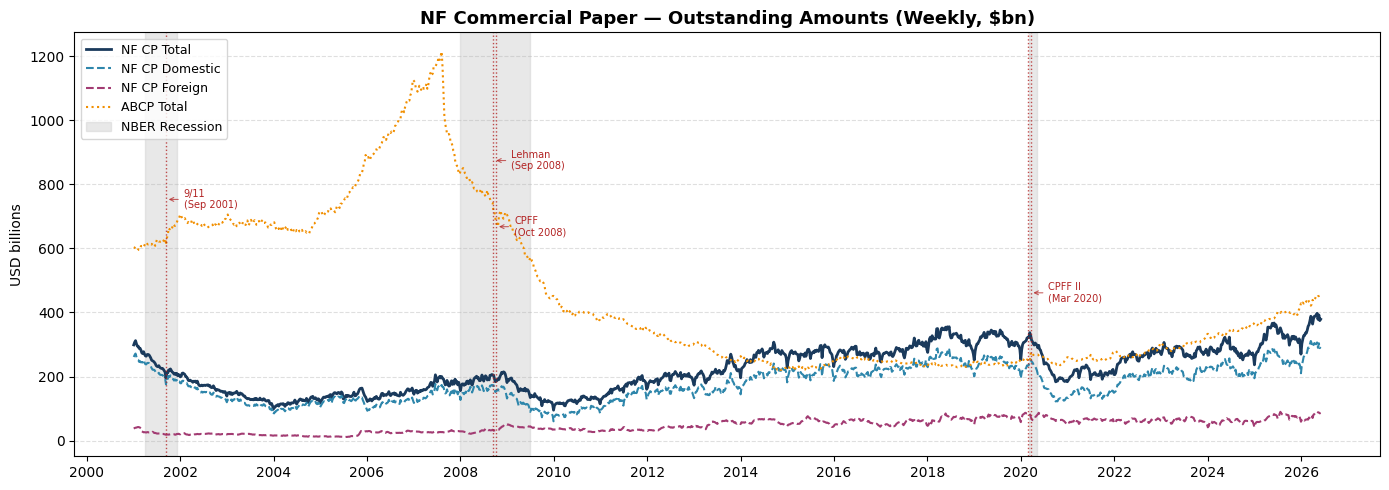

Chart saved: 6_1_outstanding_levels.png


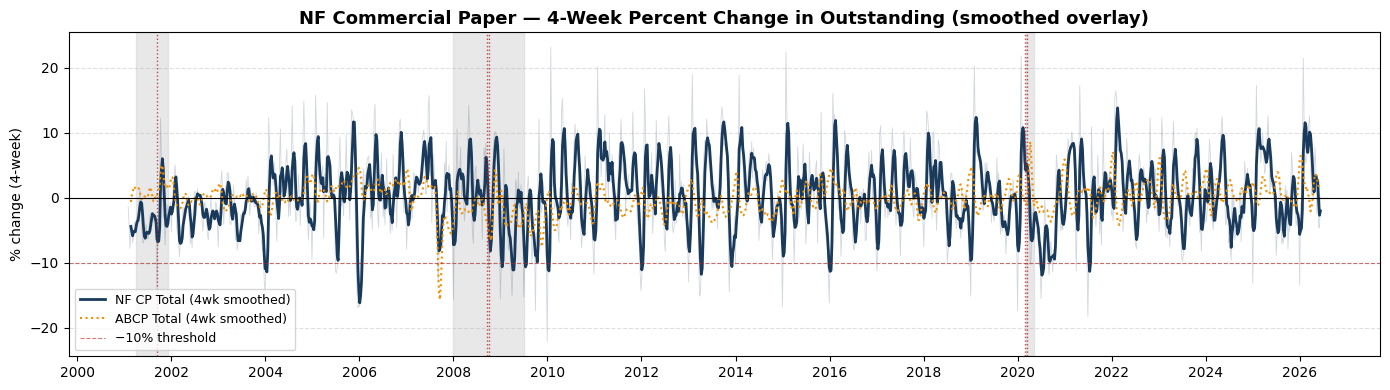


Outstanding Volume — Descriptive Statistics ($bn)
────────────────────────────────────────────────────────────
       COMPAPER  ABCOMPN
count    1327.0   1327.0
mean      223.3    455.1
std        69.6    245.3
min        95.1    219.9
25%       159.3    253.5
50%       213.9    346.6
75%       278.8    668.3
max       397.2   1213.7

Peak and Trough — COMPAPER (NF CP Total)
────────────────────────────────────────────────────────────
  All-time peak  : 2026-05-06  $397.2bn
  GFC trough     : 2009-12-30  $95.1bn
  Covid trough   : 2020-09-30  $183.4bn
  Local pre-GFC peak : 2008-09-03  $206.2bn
  GFC drawdown from local pre-GFC peak: -53.9%


In [39]:
# CELL 6.1 — Outstanding volume analysis

VOL_SERIES = {
    "COMPAPER":     "NF CP Total Outstanding",
    "DNFINCPN":     "NF CP Domestic",
    "FNFINCPN":     "NF CP Foreign",
    "DTBSPCKNONWW": "NF CP Other",
    "ABCOMPN":      "ABCP Total Outstanding",
}

vol_df = master[list(VOL_SERIES.keys())].copy()

# DTBSPCKNONWW is reported in millions — convert to billions to match all other series
vol_df["DTBSPCKNONWW"] = vol_df["DTBSPCKNONWW"] / 1000

# 4-week % change: captures meaningful drawdowns without excess noise
vol_chg = vol_df.pct_change(periods=4) * 100
vol_chg.columns = [f"{c}_4wchg" for c in vol_chg.columns]

usrec = load_series("USREC").reindex(master.index, method="ffill")["USREC"]

EVENTS = {
    "9/11\n(Sep 2001)":    "2001-09-11",
    "Lehman\n(Sep 2008)":  "2008-09-15",
    "CPFF\n(Oct 2008)":    "2008-10-07",
    "Covid\n(Mar 2020)":   "2020-03-01",
    "CPFF II\n(Mar 2020)": "2020-03-17",
}

fig, ax = plt.subplots(figsize=(14, 5))
shade_recessions(ax, usrec)

ax.plot(vol_df.index, vol_df["COMPAPER"],     lw=2,   color="#1a3a5c", label="NF CP Total")
ax.plot(vol_df.index, vol_df["DNFINCPN"],     lw=1.5, color="#2e86ab", label="NF CP Domestic", linestyle="--")
ax.plot(vol_df.index, vol_df["FNFINCPN"],     lw=1.5, color="#a23b72", label="NF CP Foreign",  linestyle="--")
ax.plot(vol_df.index, vol_df["ABCOMPN"],      lw=1.5, color="#f18f01", label="ABCP Total",     linestyle=":")

for label, date in EVENTS.items():
    ax.axvline(pd.Timestamp(date), color="firebrick", lw=1, linestyle=":", alpha=0.8)

annotations_levels = {
    "9/11\n(Sep 2001)":    ("2001-09-11", 0.62),
    "Lehman\n(Sep 2008)":  ("2008-09-15", 0.72),
    "CPFF\n(Oct 2008)":    ("2008-10-07", 0.55),
    "CPFF II\n(Mar 2020)": ("2020-03-17", 0.38),
}
for label, (date, yrel) in annotations_levels.items():
    ts   = pd.Timestamp(date)
    ypos = vol_df["ABCOMPN"].max() * yrel
    xoff = pd.Timedelta(weeks=20)
    ax.annotate(label,
                xy=(ts, ypos),
                xytext=(ts + xoff, ypos),
                fontsize=7, color="firebrick", va="center",
                arrowprops=dict(arrowstyle="->", color="firebrick",
                                lw=0.8, alpha=0.7))

ax.set_title("NF Commercial Paper — Outstanding Amounts (Weekly, $bn)", fontsize=13, fontweight="bold")
ax.set_ylabel("USD billions")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
grey_patch = mpatches.Patch(color="lightgrey", alpha=0.5, label="NBER Recession")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [grey_patch], labels + ["NBER Recession"], loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "FR_6_1_outstanding_levels.png", dpi=150)
plt.show()
print("Chart saved: 6_1_outstanding_levels.png")

SMOOTH = 4

fig, ax = plt.subplots(figsize=(14, 4))
shade_recessions(ax, usrec)

ax.plot(vol_df.index, vol_chg["COMPAPER_4wchg"],
        lw=0.6, color="#1a3a5c", alpha=0.2)
ax.plot(vol_df.index,
        vol_chg["COMPAPER_4wchg"].rolling(SMOOTH).mean(),
        lw=2, color="#1a3a5c", label="NF CP Total (4wk smoothed)")
ax.plot(vol_df.index,
        vol_chg["ABCOMPN_4wchg"].rolling(SMOOTH).mean(),
        lw=1.5, color="#f18f01", label="ABCP Total (4wk smoothed)",
        linestyle=":")

ax.axhline(0,   color="black",     lw=0.8)
ax.axhline(-10, color="firebrick", lw=0.8, linestyle="--",
           alpha=0.6, label="−10% threshold")

for label, date in EVENTS.items():
    ax.axvline(pd.Timestamp(date), color="firebrick", lw=1,
               linestyle=":", alpha=0.8)

ax.set_title("NF Commercial Paper — 4-Week Percent Change in Outstanding (smoothed overlay)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("% change (4-week)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(loc="lower left", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print("\nOutstanding Volume — Descriptive Statistics ($bn)")
print("─" * 60)
print(vol_df[["COMPAPER", "ABCOMPN"]].describe().round(1).to_string())

print("\nPeak and Trough — COMPAPER (NF CP Total)")
print("─" * 60)
peak_date  = vol_df["COMPAPER"].idxmax()
trough_gfc = vol_df["COMPAPER"]["2008":"2010"].idxmin()
trough_cov = vol_df["COMPAPER"]["2020":"2020"].idxmin()
print(f"  All-time peak  : {peak_date.date()}  ${vol_df['COMPAPER'][peak_date]:.1f}bn")
print(f"  GFC trough     : {trough_gfc.date()}  ${vol_df['COMPAPER'][trough_gfc]:.1f}bn")
print(f"  Covid trough   : {trough_cov.date()}  ${vol_df['COMPAPER'][trough_cov]:.1f}bn")
peak_pregfc      = vol_df["COMPAPER"]["2005":"2008-09"].max()
peak_pregfc_date = vol_df["COMPAPER"]["2005":"2008-09"].idxmax()
drawdown_gfc     = (vol_df["COMPAPER"][trough_gfc] / peak_pregfc - 1) * 100
print(f"  Local pre-GFC peak : {peak_pregfc_date.date()}  ${peak_pregfc:.1f}bn")
print(f"  GFC drawdown from local pre-GFC peak: {drawdown_gfc:.1f}%")

### 6.2 Issuance Flows and Maturity Structure

Issuance is a flow signal: where outstanding volume measures market size, issuance captures whether new deals are getting done and at what tenor. Under stress, investors refuse longer maturities and issuers are forced into overnight or very short paper just to keep rolling — visible as short buckets rising and long buckets collapsing as a share of total weekly issuance.

Three charts are produced: monthly issuance by maturity bucket (stacked area), short-maturity share for AA vs A2/P2, and total weekly issuance flow by grade.

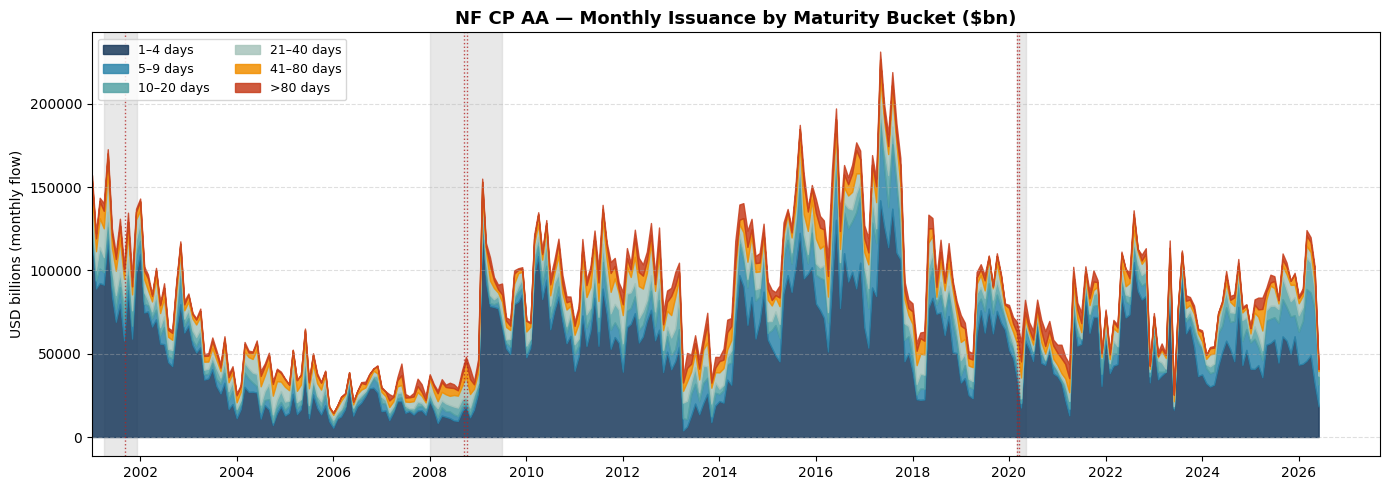

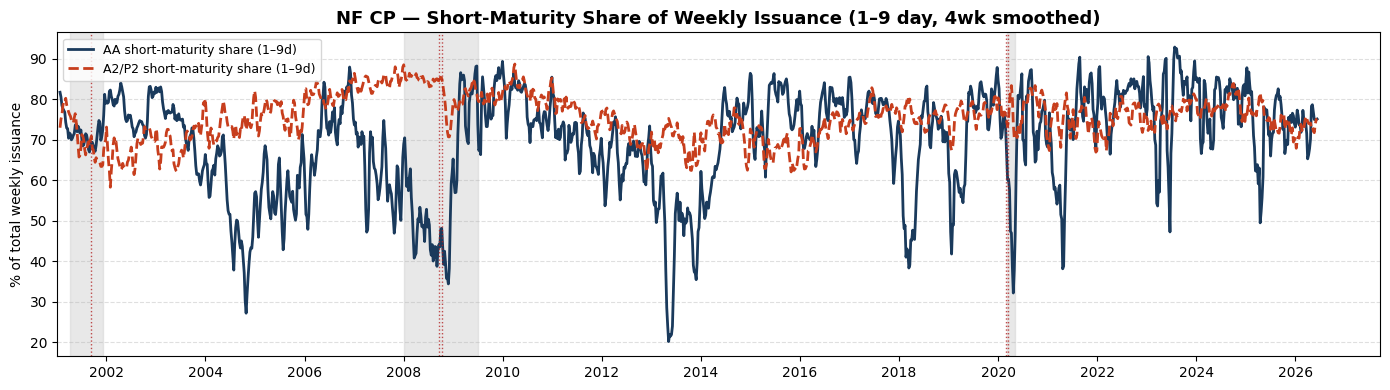

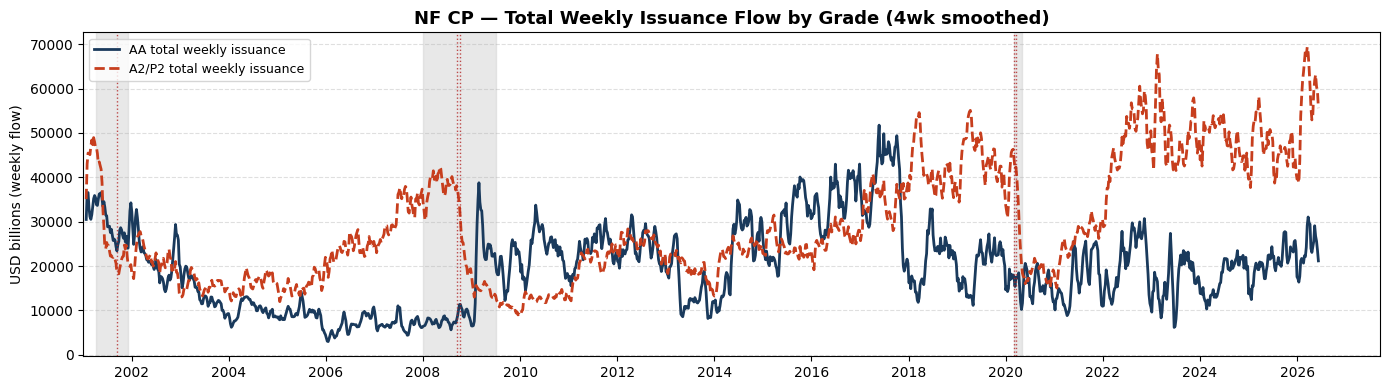


Maturity Share Summary — AA (mean % across full sample)
──────────────────────────────────────────────────
  1–4 days          58.6%
  5–9 days          11.2%
  10–20 days         8.2%
  21–40 days        10.8%
  41–80 days         7.0%
  >80 days           4.2%

Short-Maturity Share (1–9 day) — Stress Episode Peaks
──────────────────────────────────────────────────
  Full-sample mean : 69.8%
  GFC peak         : 99.9%
  Covid peak       : 90.1%


In [40]:
# CELL 6.2 — Issuance flows and maturity structure

BUCKETS = ["14", "59", "1020", "2140", "4180", "GT80"]
BUCKET_LABELS = {
    "14":   "1–4 days",
    "59":   "5–9 days",
    "1020": "10–20 days",
    "2140": "21–40 days",
    "4180": "41–80 days",
    "GT80": ">80 days",
}
BUCKET_COLORS = {
    "14":   "#1a3a5c",
    "59":   "#2e86ab",
    "1020": "#56a3a6",
    "2140": "#a8c5bc",
    "4180": "#f18f01",
    "GT80": "#c73e1d",
}

SHORT_BUCKETS = ["14", "59"]
LONG_BUCKETS  = ["4180", "GT80"]

aa_amt  = master[[f"NONFIN{b}AAAMT"   for b in BUCKETS]].copy()
a2_amt  = master[[f"NONFIN{b}A2P2AMT" for b in BUCKETS]].copy()
aa_vol  = master[[f"NONFIN{b}AAVOL"   for b in BUCKETS]].copy()
a2_vol  = master[[f"NONFIN{b}A2P2VOL" for b in BUCKETS]].copy()

aa_amt.columns = BUCKETS
a2_amt.columns = BUCKETS
aa_vol.columns = BUCKETS
a2_vol.columns = BUCKETS

# Issuance series have no data in 2000 — restrict to 2001 onwards
aa_amt = aa_amt["2001":]
a2_amt = a2_amt["2001":]
aa_vol = aa_vol["2001":]
a2_vol = a2_vol["2001":]

def maturity_shares(df):
    total = df.sum(axis=1)
    shares = df.div(total, axis=0) * 100
    shares[total == 0] = np.nan  # weeks with no issuance — avoid 0/0
    return shares

share_aa = maturity_shares(aa_amt)
share_a2 = maturity_shares(a2_amt)

short_share_aa = share_aa[SHORT_BUCKETS].sum(axis=1)
short_share_a2 = share_a2[SHORT_BUCKETS].sum(axis=1)

# Monthly aggregation for stacked area chart — units remain $bn per month
aa_amt_monthly = aa_amt.resample("MS").sum()

SMOOTH = 4

fig, ax = plt.subplots(figsize=(14, 5))
shade_recessions(ax, usrec)

bottom = pd.Series(0.0, index=aa_amt_monthly.index)
for bucket in BUCKETS:
    vals = aa_amt_monthly[bucket].fillna(0)
    ax.fill_between(aa_amt_monthly.index, bottom, bottom + vals,
                    label=BUCKET_LABELS[bucket],
                    color=BUCKET_COLORS[bucket], alpha=0.85)
    bottom = bottom + vals

for label, date in EVENTS.items():
    ax.axvline(pd.Timestamp(date), color="firebrick", lw=1, linestyle=":", alpha=0.8)

ax.set_title("NF CP AA — Monthly Issuance by Maturity Bucket ($bn)", fontsize=13, fontweight="bold")
ax.set_ylabel("USD billions (monthly flow)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.set_xlim(pd.Timestamp("2001-01-01"), None)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
shade_recessions(ax, usrec)

ax.plot(short_share_aa.index,
        short_share_aa.rolling(SMOOTH).mean(),
        lw=2, color="#1a3a5c", label="AA short-maturity share (1–9d)")
ax.plot(short_share_a2.index,
        short_share_a2.rolling(SMOOTH).mean(),
        lw=2, color="#c73e1d", label="A2/P2 short-maturity share (1–9d)", linestyle="--")

for label, date in EVENTS.items():
    ax.axvline(pd.Timestamp(date), color="firebrick", lw=1, linestyle=":", alpha=0.8)

ax.set_title("NF CP — Short-Maturity Share of Weekly Issuance (1–9 day, 4wk smoothed)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("% of total weekly issuance")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(pd.Timestamp("2001-01-01"), None)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

total_aa = aa_amt.sum(axis=1)
total_a2 = a2_amt.sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 4))
shade_recessions(ax, usrec)

ax.plot(total_aa.index,
        total_aa.rolling(SMOOTH).mean(),
        lw=2, color="#1a3a5c", label="AA total weekly issuance")
ax.plot(total_a2.index,
        total_a2.rolling(SMOOTH).mean(),
        lw=2, color="#c73e1d", label="A2/P2 total weekly issuance", linestyle="--")

for label, date in EVENTS.items():
    ax.axvline(pd.Timestamp(date), color="firebrick", lw=1, linestyle=":", alpha=0.8)

ax.set_title("NF CP — Total Weekly Issuance Flow by Grade (4wk smoothed)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("USD billions (weekly flow)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(pd.Timestamp("2001-01-01"), None)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print("\nMaturity Share Summary — AA (mean % across full sample)")
print("─" * 50)
for bucket in BUCKETS:
    print(f"  {BUCKET_LABELS[bucket]:<15} {share_aa[bucket].mean():>6.1f}%")

print("\nShort-Maturity Share (1–9 day) — Stress Episode Peaks")
print("─" * 50)
print(f"  Full-sample mean : {short_share_aa.mean():.1f}%")
print(f"  GFC peak         : {short_share_aa['2008':'2009'].max():.1f}%")
print(f"  Covid peak       : {short_share_aa['2020':'2020'].max():.1f}%")

### 6.3 Spread Decomposition

Four spread families are examined, each capturing a distinct dimension of stress:

- **Quality spread** (A2/P2 − AA, same tenor): premium for lower credit quality; spikes during flight-to-quality episodes
- **Risk premium** (AA − DFF): premium even safe CP pays over risk-free; spikes when the whole CP market is avoided regardless of issuer quality
- **Full borrower spread** (A2/P2 − DFF): total funding cost faced by a stressed NF firm relative to risk-free; equals quality spread plus risk premium by construction
- **Term spread** (30d − overnight, AA and A2/P2): premium for longer commitment; collapses or inverts under stress when investors refuse to commit beyond overnight

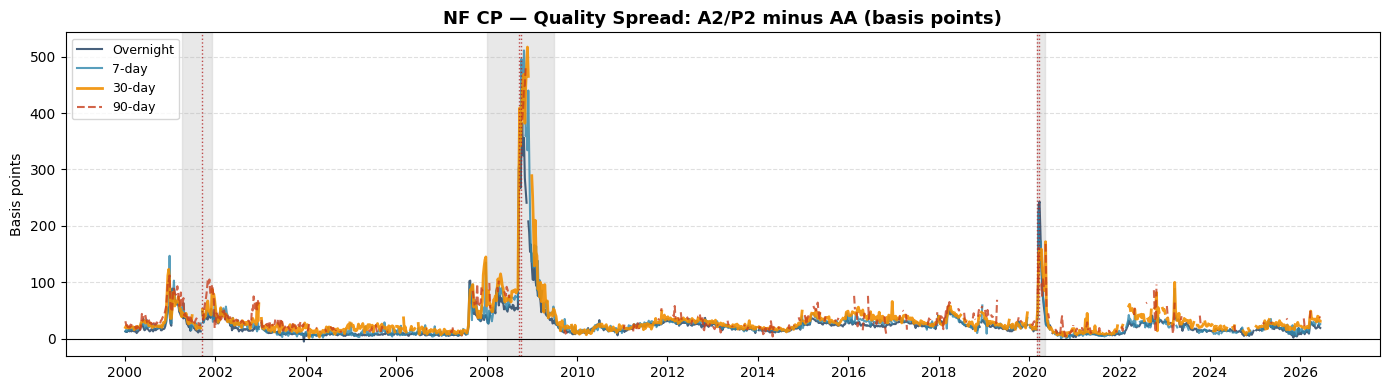

Chart saved: 6_3_quality_spread.png


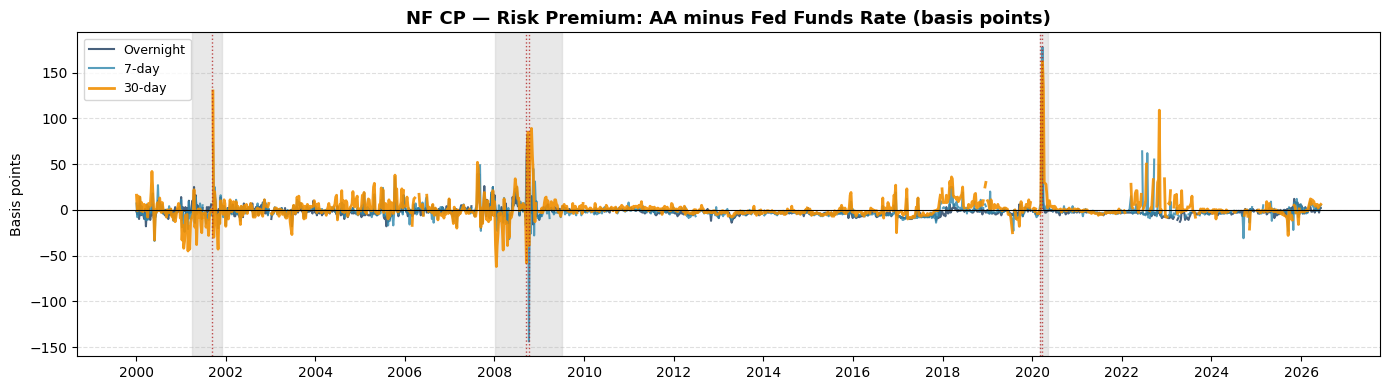

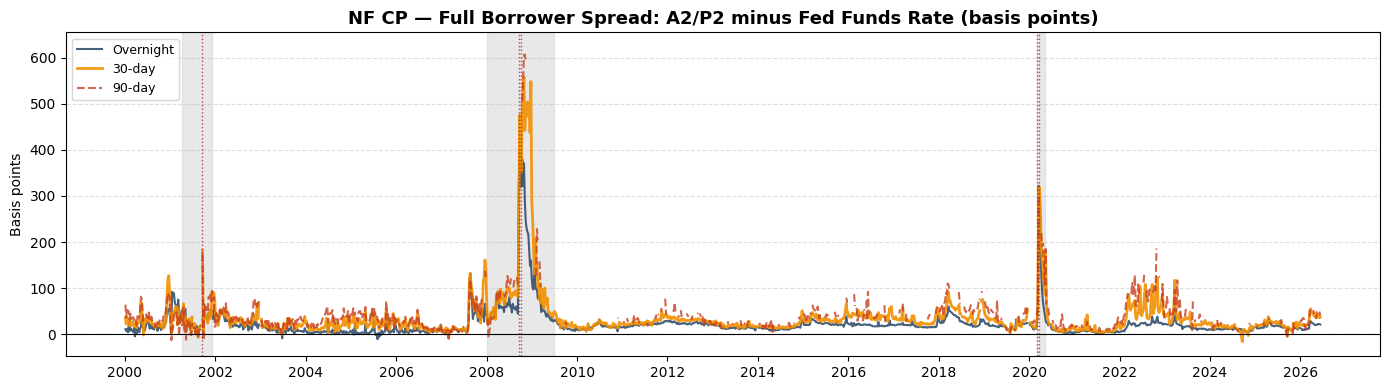

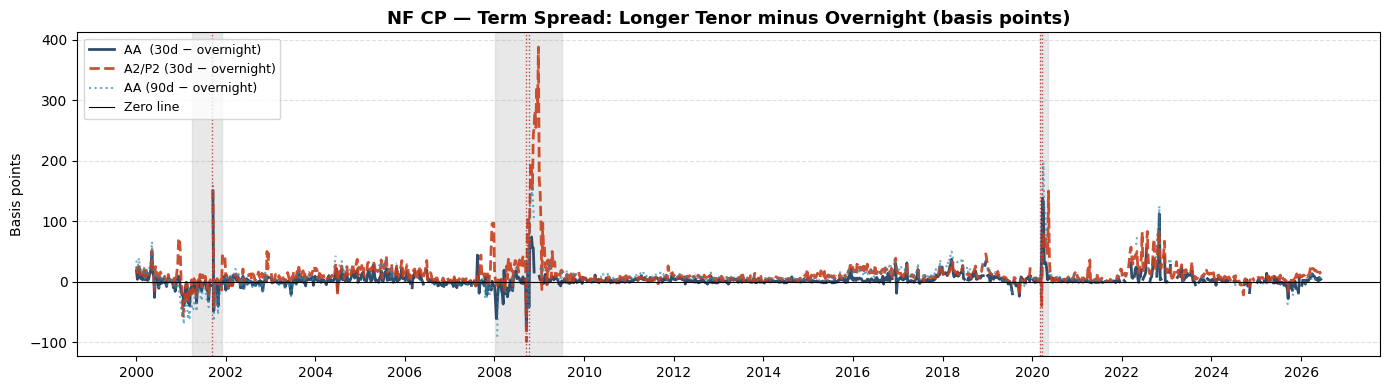


Spread Summary Statistics (basis points)
────────────────────────────────────────────────────────────
       qual_30  qual_90   rp_30  full_30  term_aa  term_a2
count   1271.0    674.0  1271.0   1362.0   1262.0   1362.0
mean      34.9     38.9     1.1     36.0      2.9     13.4
std       46.7     43.9    13.6     53.8     12.5     27.4
min        2.0      2.0   -62.0    -16.0    -77.0    -99.0
25%       18.0     20.0    -3.0     17.0     -1.0      4.0
50%       25.0     29.0    -1.0     25.0      2.0      8.0
75%       36.0     43.0     3.0     36.0      5.0     16.0
max      517.0    485.0   162.0    558.0    149.0    388.0

Stress Episode Peaks (basis points)
────────────────────────────────────────────────────────────
  Quality 30d             mean=  34.9  GFC peak=  517.0  Covid peak=  172.0
  Risk prem 30d           mean=   1.1  GFC peak=   89.0  Covid peak=  162.0
  Full borrower 30d       mean=  36.0  GFC peak=  558.0  Covid peak=  319.0
  Term AA                 mean=   2.9  G

In [41]:
# CELL 6.3 — Spread decomposition

# AA rates
aa_on  = master["RIFSPPNAAD01NB"]
aa_07  = master["RIFSPPNAAD07NB"]
aa_30  = master["RIFSPPNAAD30NB"]
aa_60  = master["DCPN2M"]
aa_90  = master["DCPN3M"]

# A2/P2 rates
a2_on  = master["RIFSPPNA2P2D01NB"]
a2_07  = master["RIFSPPNA2P2D07NB"]
a2_30  = master["RIFSPPNA2P2D30NB"]
a2_60  = master["RIFSPPNA2P2D60NB"]
a2_90  = master["RIFSPPNA2P2D90NB"]

dff    = master["DFF"]

# Quality spreads — A2/P2 minus AA, by tenor (basis points)
qual_on  = (a2_on  - aa_on)  * 100
qual_07  = (a2_07  - aa_07)  * 100
qual_30  = (a2_30  - aa_30)  * 100
qual_60  = (a2_60  - aa_60)  * 100
qual_90  = (a2_90  - aa_90)  * 100

# Risk premium — AA minus DFF, by tenor
rp_on    = (aa_on  - dff)    * 100
rp_07    = (aa_07  - dff)    * 100
rp_30    = (aa_30  - dff)    * 100

# Full borrower spread — A2/P2 minus DFF, by tenor
full_on  = (a2_on  - dff)    * 100
full_30  = (a2_30  - dff)    * 100
full_90  = (a2_90  - dff)    * 100

# Term spreads — longer tenor minus overnight
term_aa    = (aa_30  - aa_on)  * 100
term_a2    = (a2_30  - a2_on)  * 100
term_aa_90 = (aa_90  - aa_on)  * 100

fig, ax = plt.subplots(figsize=(14, 4))
shade_recessions(ax, usrec)

ax.plot(qual_on.index, qual_on, lw=1.5, color="#1a3a5c", label="Overnight", alpha=0.8)
ax.plot(qual_07.index, qual_07, lw=1.5, color="#2e86ab", label="7-day",     alpha=0.8)
ax.plot(qual_30.index, qual_30, lw=2,   color="#f18f01", label="30-day",    alpha=0.9)
ax.plot(qual_90.index, qual_90, lw=1.5, color="#c73e1d", label="90-day",    alpha=0.8,
        linestyle="--")
ax.axhline(0, color="black", lw=0.8)

for label, date in EVENTS.items():
    ax.axvline(pd.Timestamp(date), color="firebrick", lw=1, linestyle=":", alpha=0.8)

ax.set_title("NF CP — Quality Spread: A2/P2 minus AA (basis points)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Basis points")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "FR_6_3_quality_spread.png", dpi=150)
plt.show()
print("Chart saved: 6_3_quality_spread.png")

fig, ax = plt.subplots(figsize=(14, 4))
shade_recessions(ax, usrec)

ax.plot(rp_on.index, rp_on, lw=1.5, color="#1a3a5c", label="Overnight", alpha=0.8)
ax.plot(rp_07.index, rp_07, lw=1.5, color="#2e86ab", label="7-day",     alpha=0.8)
ax.plot(rp_30.index, rp_30, lw=2,   color="#f18f01", label="30-day",    alpha=0.9)
ax.axhline(0, color="black", lw=0.8)

for label, date in EVENTS.items():
    ax.axvline(pd.Timestamp(date), color="firebrick", lw=1, linestyle=":", alpha=0.8)

ax.set_title("NF CP — Risk Premium: AA minus Fed Funds Rate (basis points)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Basis points")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
shade_recessions(ax, usrec)

ax.plot(full_on.index, full_on, lw=1.5, color="#1a3a5c", label="Overnight", alpha=0.8)
ax.plot(full_30.index, full_30, lw=2,   color="#f18f01", label="30-day",    alpha=0.9)
ax.plot(full_90.index, full_90, lw=1.5, color="#c73e1d", label="90-day",    alpha=0.8,
        linestyle="--")
ax.axhline(0, color="black", lw=0.8)

for label, date in EVENTS.items():
    ax.axvline(pd.Timestamp(date), color="firebrick", lw=1, linestyle=":", alpha=0.8)

ax.set_title("NF CP — Full Borrower Spread: A2/P2 minus Fed Funds Rate (basis points)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Basis points")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
shade_recessions(ax, usrec)

ax.plot(term_aa.index,    term_aa,    lw=2,   color="#1a3a5c", label="AA  (30d − overnight)",   alpha=0.9)
ax.plot(term_a2.index,    term_a2,    lw=2,   color="#c73e1d", label="A2/P2 (30d − overnight)", alpha=0.9,
        linestyle="--")
ax.plot(term_aa_90.index, term_aa_90, lw=1.5, color="#2e86ab", label="AA (90d − overnight)",    alpha=0.7,
        linestyle=":")
ax.axhline(0, color="black", lw=0.8, label="Zero line")

for label, date in EVENTS.items():
    ax.axvline(pd.Timestamp(date), color="firebrick", lw=1, linestyle=":", alpha=0.8)

ax.set_title("NF CP — Term Spread: Longer Tenor minus Overnight (basis points)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Basis points")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

spreads_summary = pd.DataFrame({
    "qual_30": qual_30,
    "qual_90": qual_90,
    "rp_30":   rp_30,
    "full_30": full_30,
    "term_aa": term_aa,
    "term_a2": term_a2,
}).dropna(how="all")

print("\nSpread Summary Statistics (basis points)")
print("─" * 60)
print(spreads_summary.describe().round(1).to_string())

print("\nStress Episode Peaks (basis points)")
print("─" * 60)
for name, s in [("Quality 30d",        qual_30),
                ("Risk prem 30d",      rp_30),
                ("Full borrower 30d",  full_30),
                ("Term AA",            term_aa)]:
    gfc  = s["2008":"2009"].max()
    cov  = s["2020":"2020"].max()
    mean = s.mean()
    print(f"  {name:<22}  mean={mean:>6.1f}  GFC peak={gfc:>7.1f}  Covid peak={cov:>7.1f}")

### 6.4 Composite Stress Index

The CSI aggregates the three measurement layers into a single weekly stress score. Each component is z-scored over the full sample so readings are in standard deviation units relative to the long-run mean. Volume is inverted so that all components point in the same stress direction. The final index is an equal-weighted average of the three z-scores.

Three components enter the index:

- **vol_z**: 4-week percent change in COMPAPER (inverted)
- **qual_z**: quality spread 30d (A2/P2 − AA)
- **rp_z**: risk premium 30d (AA − DFF)

Where fewer than two components are available the index is set to NaN; otherwise the average of available components is used.

/var/folders/p1/ltsd18qs7f39qblxj66m_0d40000gq/T/ipykernel_15656/3275551172.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  vol_4w = vol_df["COMPAPER"].pct_change(periods=4) * 100


Component coverage (non-NaN weeks):
───────────────────────────────────────────────────────
  vol_chg       1324 weeks (95.9%)  [2001-01-31 → 2026-06-10]
  qual_30       1271 weeks (92.1%)  [2000-01-05 → 2026-06-10]
  rp_30         1271 weeks (92.1%)  [2000-01-05 → 2026-06-10]

CSI coverage:
  Strict (all 3)  : 1215 weeks
  Flexible (≥2/3) : 1271 weeks

Stress thresholds (CSI):
  90th percentile : 0.515  (128 weeks)
  95th percentile : 0.800  (64 weeks)
  99th percentile : 2.773


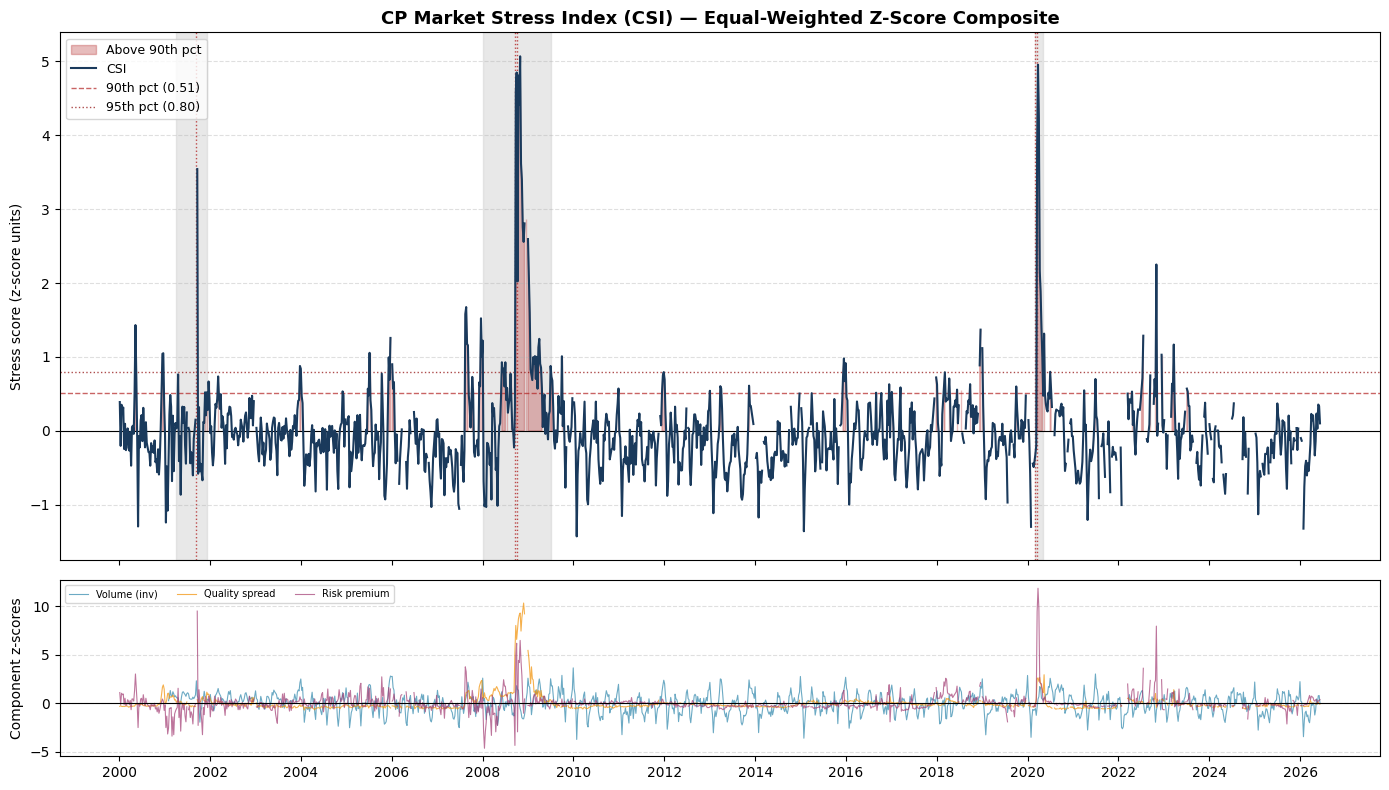

Chart saved: 6_4_csi_full.png


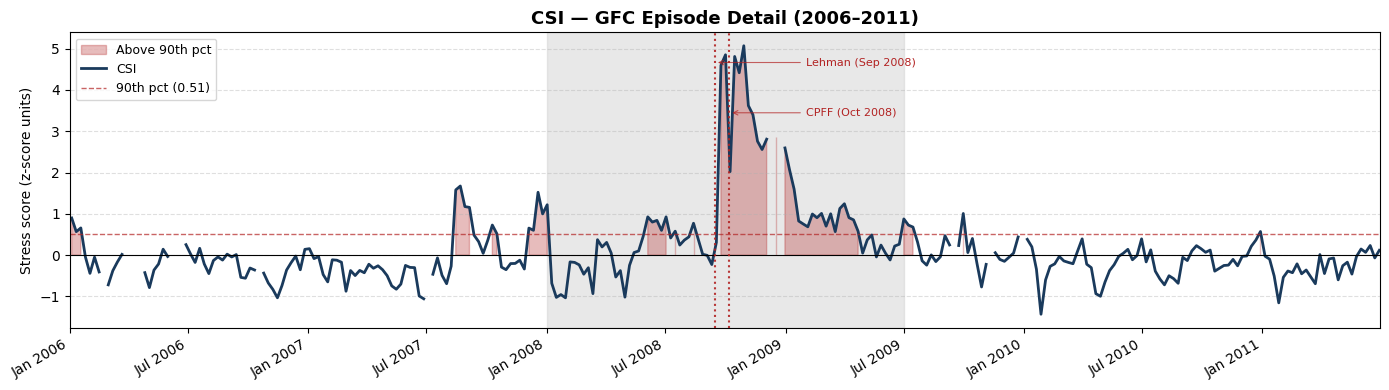

Chart saved: 6_4_csi_gfc.png


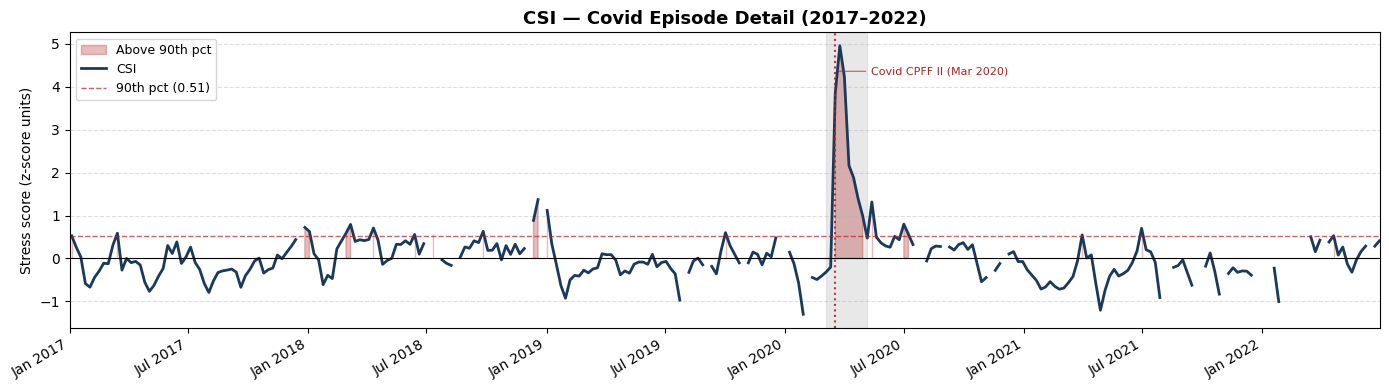

Chart saved: 6_4_csi_covid.png

Composite Stress Index — Summary
──────────────────────────────────────────────────
count    1271.000
mean       -0.008
std         0.630
min        -1.429
25%        -0.328
50%        -0.074
75%         0.196
max         5.069

Top 10 stress weeks:
──────────────────────────────────────────────────
  2008-10-29   CSI = 5.069
  2020-03-25   CSI = 4.954
  2008-10-01   CSI = 4.850
  2008-10-15   CSI = 4.809
  2008-09-24   CSI = 4.595
  2008-10-22   CSI = 4.416
  2020-04-01   CSI = 4.234
  2020-03-18   CSI = 3.847
  2008-11-05   CSI = 3.619
  2001-09-19   CSI = 3.543

Component means during stress episodes:
──────────────────────────────────────────────────

  9/11  (Sep–Dec 2001)
    vol_z        0.319
    qual_z       0.391
    rp_z         0.178

  GFC   (Sep–Dec 2008)
    vol_z       -0.042
    qual_z       7.261
    rp_z         1.520

  Covid (Mar–Apr 2020)
    vol_z        0.345
    qual_z       1.728
    rp_z         4.244

Saved: /Users/leo/Desktop

In [42]:
# CELL 6.4 — Z-score normalization and composite stress index

vol_4w = vol_df["COMPAPER"].pct_change(periods=4) * 100

components_raw = pd.DataFrame({
    "vol_chg": vol_4w,
    "qual_30": qual_30,
    "rp_30":   rp_30,
}, index=master.index)

print("Component coverage (non-NaN weeks):")
print("─" * 55)
for col in components_raw.columns:
    n     = components_raw[col].notna().sum()
    first = components_raw[col].first_valid_index()
    last  = components_raw[col].last_valid_index()
    pct   = n / len(components_raw) * 100
    print(f"  {col:<12} {n:>5} weeks ({pct:.1f}%)  [{first.date()} → {last.date()}]")

def zscore(series: pd.Series) -> pd.Series:
    """Z-score using full-sample mean and std. Index is retrospective by design."""
    return (series - series.mean()) / series.std()

vol_z  = zscore(vol_4w)
qual_z = zscore(qual_30)
rp_z   = zscore(rp_30)

vol_z_inv = -vol_z

components_z = pd.DataFrame({
    "vol_z":  vol_z_inv,
    "qual_z": qual_z,
    "rp_z":   rp_z,
}, index=master.index)

# Strict: require all 3 components
csi_strict = components_z.mean(axis=1, skipna=False)

# Flexible: require at least 2 of 3
def flexible_mean(row, min_valid=2):
    valid = row.dropna()
    return valid.mean() if len(valid) >= min_valid else np.nan

csi_flex = components_z.apply(flexible_mean, axis=1)

print(f"\nCSI coverage:")
print(f"  Strict (all 3)  : {csi_strict.notna().sum()} weeks")
print(f"  Flexible (≥2/3) : {csi_flex.notna().sum()} weeks")

csi = csi_flex.copy()
csi.name = "CSI"

threshold_90 = csi.quantile(0.90)
threshold_95 = csi.quantile(0.95)
threshold_99 = csi.quantile(0.99)

stress_90 = (csi >= threshold_90)
stress_95 = (csi >= threshold_95)

print(f"\nStress thresholds (CSI):")
print(f"  90th percentile : {threshold_90:.3f}  ({stress_90.sum()} weeks)")
print(f"  95th percentile : {threshold_95:.3f}  ({stress_95.sum()} weeks)")
print(f"  99th percentile : {threshold_99:.3f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

shade_recessions(ax1, usrec)
ax1.fill_between(csi.index, csi, 0,
                 where=(csi > threshold_90),
                 color="firebrick", alpha=0.3, label="Above 90th pct")
ax1.plot(csi.index, csi, lw=1.5, color="#1a3a5c", label="CSI", zorder=3)
ax1.axhline(threshold_90, color="firebrick", lw=1, linestyle="--",
            alpha=0.7, label=f"90th pct ({threshold_90:.2f})")
ax1.axhline(threshold_95, color="darkred",   lw=1, linestyle=":",
            alpha=0.7, label=f"95th pct ({threshold_95:.2f})")
ax1.axhline(0, color="black", lw=0.8)

for label, date in EVENTS.items():
    ax1.axvline(pd.Timestamp(date), color="firebrick", lw=1,
                linestyle=":", alpha=0.8)

ax1.set_title("CP Market Stress Index (CSI) — Equal-Weighted Z-Score Composite",
              fontsize=13, fontweight="bold")
ax1.set_ylabel("Stress score (z-score units)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

for col, color, label in [
    ("vol_z",  "#2e86ab", "Volume (inv)"),
    ("qual_z", "#f18f01", "Quality spread"),
    ("rp_z",   "#a23b72", "Risk premium"),
]:
    ax2.plot(components_z.index, components_z[col],
             lw=0.8, color=color, alpha=0.7, label=label)

ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Component z-scores")
ax2.legend(loc="upper left", fontsize=7, ncol=3)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "FR_6_4_csi_full.png", dpi=150)
plt.show()
print("Chart saved: 6_4_csi_full.png")

fig, ax = plt.subplots(figsize=(14, 4))
mask = (csi.index >= "2006-01-01") & (csi.index <= "2011-06-30")
shade_recessions(ax, usrec)

ax.fill_between(csi.index[mask], csi[mask], 0,
                where=(csi[mask] > threshold_90),
                color="firebrick", alpha=0.3, label="Above 90th pct")
ax.plot(csi.index[mask], csi[mask], lw=2, color="#1a3a5c", label="CSI")
ax.axhline(threshold_90, color="firebrick", lw=1, linestyle="--",
           alpha=0.7, label=f"90th pct ({threshold_90:.2f})")
ax.axhline(0, color="black", lw=0.8)

annotations = {
    "Lehman (Sep 2008)": ("2008-09-15", 0.92),
    "CPFF (Oct 2008)":   ("2008-10-07", 0.68),
}
for label, (date, yrel) in annotations.items():
    ts   = pd.Timestamp(date)
    ypos = csi[mask].max() * yrel
    ax.axvline(ts, color="firebrick", lw=1.5, linestyle=":", alpha=0.9)
    ax.annotate(label,
                xy=(ts, ypos),
                xytext=(pd.Timestamp("2009-02-01"), ypos),
                fontsize=8, color="firebrick", va="center",
                arrowprops=dict(arrowstyle="->", color="firebrick",
                                lw=0.8, alpha=0.7))

ax.set_title("CSI — GFC Episode Detail (2006–2011)", fontsize=13, fontweight="bold")
ax.set_ylabel("Stress score (z-score units)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_xlim(pd.Timestamp("2006-01-01"), pd.Timestamp("2011-06-30"))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "FR_6_4_csi_gfc.png", dpi=150)
plt.show()
print("Chart saved: 6_4_csi_gfc.png")

fig, ax = plt.subplots(figsize=(14, 4))
mask = (csi.index >= "2017-01-01") & (csi.index <= "2022-06-30")
shade_recessions(ax, usrec)

ax.fill_between(csi.index[mask], csi[mask], 0,
                where=(csi[mask] > threshold_90),
                color="firebrick", alpha=0.3, label="Above 90th pct")
ax.plot(csi.index[mask], csi[mask], lw=2, color="#1a3a5c", label="CSI")
ax.axhline(threshold_90, color="firebrick", lw=1, linestyle="--",
           alpha=0.7, label=f"90th pct ({threshold_90:.2f})")
ax.axhline(0, color="black", lw=0.8)

annotations_covid = {
    "Covid CPFF II (Mar 2020)": ("2020-03-17", "right", 0.88),
}
for label, (date, side, yrel) in annotations_covid.items():
    ts   = pd.Timestamp(date)
    ypos = csi[mask].max() * yrel
    xoff = pd.Timedelta(weeks=8) if side == "right" else pd.Timedelta(weeks=-8)
    ax.axvline(ts, color="firebrick", lw=1.5, linestyle=":", alpha=0.9)
    ax.annotate(label,
                xy=(ts, ypos),
                xytext=(ts + xoff, ypos),
                fontsize=8, color="firebrick", va="center",
                arrowprops=dict(arrowstyle="-", color="firebrick",
                                lw=0.8, alpha=0.7))

ax.set_title("CSI — Covid Episode Detail (2017–2022)", fontsize=13, fontweight="bold")
ax.set_ylabel("Stress score (z-score units)")
ax.set_xlim(pd.Timestamp("2017-01-01"), pd.Timestamp("2022-06-30"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "FR_6_4_csi_covid.png", dpi=150)
plt.show()
print("Chart saved: 6_4_csi_covid.png")

print("\nComposite Stress Index — Summary")
print("─" * 50)
print(csi.describe().round(3).to_string())

print(f"\nTop 10 stress weeks:")
print("─" * 50)
top10 = csi.nlargest(10)
for date, val in top10.items():
    print(f"  {date.date()}   CSI = {val:.3f}")

print("\nComponent means during stress episodes:")
print("─" * 50)
for episode, start, end in [
        ("9/11  (Sep–Dec 2001)",   "2001-09-01", "2001-12-31"),
        ("GFC   (Sep–Dec 2008)",   "2008-09-01", "2008-12-31"),
        ("Covid (Mar–Apr 2020)",   "2020-03-01", "2020-04-30"),
    ]:
    print(f"\n  {episode}")
    for col in components_z.columns:
        print(f"    {col:<10} {components_z[col][start:end].mean():>7.3f}")

csi_df = pd.DataFrame({
    "CSI":       csi,
    "stress_90": stress_90.astype(int),
    "stress_95": stress_95.astype(int),
}, index=master.index)

csi_path = DATA_DIR / "FR_csi.csv"
csi_df.to_csv(csi_path)
print(f"\nSaved: {csi_path}")

### 6.5 PCA Validation

PCA is run on the same three z-scored components to validate that the equal-weighting choice is not driving the index. If PC1 correlates highly with the CSI, the common factor is in the data itself rather than the construction.

PCA input: 1215 weeks x 3 components
Sample: 2001-01-31 → 2026-06-10

Variance explained:
  PC1 : 42.5%
  PC2 : 32.4%
  PC3 : 25.0%
  PC1+PC2 : 75.0%

PC1 loadings:
───────────────────────────────────
  vol_z        0.1300
  qual_z       0.7273
  rp_z         0.6739

PC1 vs CSI correlation:
  Pearson  : 0.9089
  Spearman : 0.8040
  ✓ Strong validation — weighting choice is not driving the index


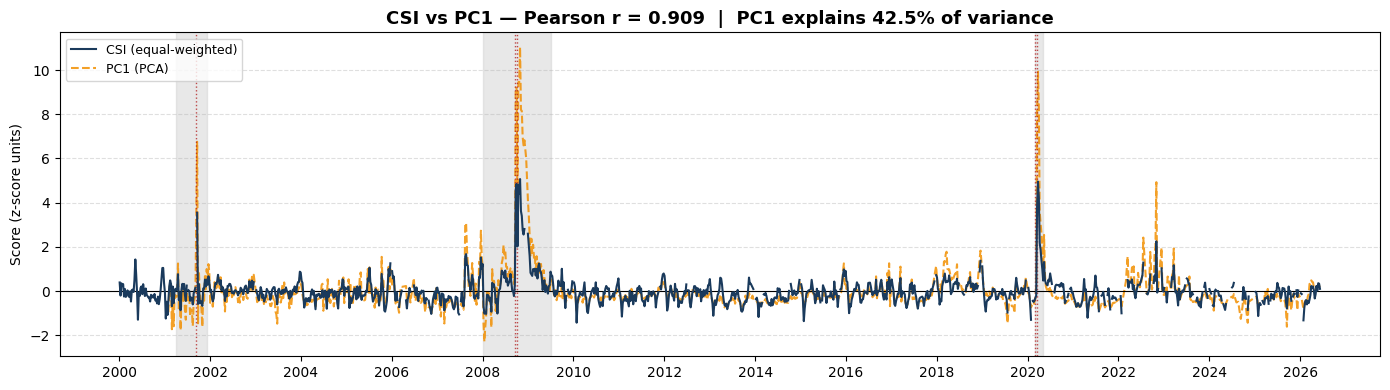

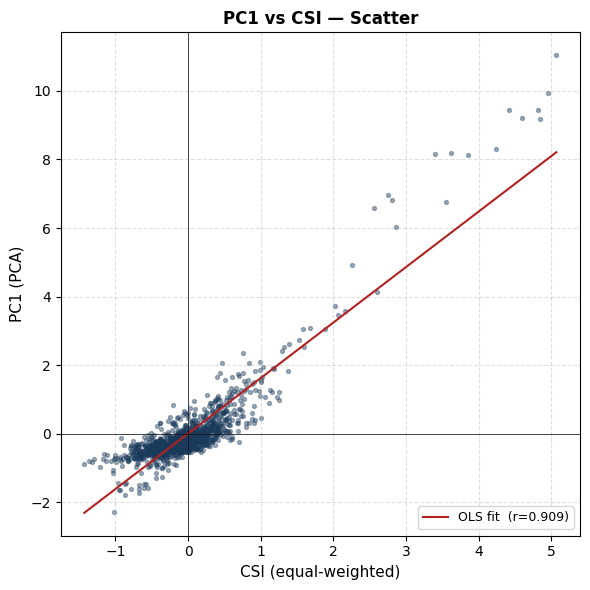

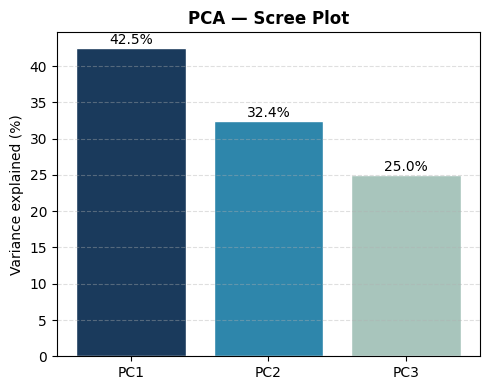


Updated: /Users/leo/Desktop/Thesis/Analysis/data/FR_csi.csv  (added PC1 column)

Loadings summary:
───────────────────────────────────
           PC1     PC2     PC3
vol_z   0.1300  0.9770  0.1690
qual_z  0.7273  0.0219 -0.6860
rp_z    0.6739 -0.2120  0.7077


In [43]:
# CELL 6.5 — PCA validation

# PCA requires a complete matrix — restrict to rows where all 3 components are present
pca_input = components_z[["vol_z", "qual_z", "rp_z"]].dropna()

print(f"PCA input: {pca_input.shape[0]} weeks x {pca_input.shape[1]} components")
print(f"Sample: {pca_input.index[0].date()} → {pca_input.index[-1].date()}")

# Components are already z-scored — no additional scaling needed
pca = PCA(n_components=3)
pc_scores = pca.fit_transform(pca_input.values)

pc1 = pd.Series(pc_scores[:, 0], index=pca_input.index, name="PC1")
pc2 = pd.Series(pc_scores[:, 1], index=pca_input.index, name="PC2")

var_explained = pca.explained_variance_ratio_ * 100
loadings      = pd.DataFrame(
    pca.components_.T,
    index=["vol_z", "qual_z", "rp_z"],
    columns=["PC1", "PC2", "PC3"]
)

print(f"\nVariance explained:")
print(f"  PC1 : {var_explained[0]:.1f}%")
print(f"  PC2 : {var_explained[1]:.1f}%")
print(f"  PC3 : {var_explained[2]:.1f}%")
print(f"  PC1+PC2 : {sum(var_explained[:2]):.1f}%")

print(f"\nPC1 loadings:")
print("─" * 35)
for comp, val in loadings["PC1"].items():
    print(f"  {comp:<10}  {val:>7.4f}")

# Align PC1 sign to stress-up convention (positive = more stress)
csi_overlap = csi.reindex(pc1.index).dropna()
pc1_overlap  = pc1.reindex(csi_overlap.index)

if pc1_overlap.corr(csi_overlap) < 0:
    pc1 = -pc1
    loadings["PC1"] = -loadings["PC1"]
    print("\n  [note] PC1 sign flipped to align with stress-up convention")

corr_pearson  = pc1_overlap.corr(csi_overlap)
corr_spearman = pc1_overlap.corr(csi_overlap, method="spearman")

print(f"\nPC1 vs CSI correlation:")
print(f"  Pearson  : {corr_pearson:.4f}")
print(f"  Spearman : {corr_spearman:.4f}")

if corr_pearson >= 0.90:
    print(f"  ✓ Strong validation — weighting choice is not driving the index")
elif corr_pearson >= 0.80:
    print(f"  ~ Moderate validation — index broadly consistent with PCA")
else:
    print(f"  ! Low correlation — review component selection")

fig, ax = plt.subplots(figsize=(14, 4))
shade_recessions(ax, usrec)

ax.plot(csi.index, csi, lw=1.5, color="#1a3a5c", label="CSI (equal-weighted)", zorder=3)
ax.plot(pc1.index, pc1, lw=1.5, color="#f18f01", label="PC1 (PCA)",
        linestyle="--", alpha=0.85, zorder=2)
ax.axhline(0, color="black", lw=0.8)

for label, date in EVENTS.items():
    ax.axvline(pd.Timestamp(date), color="firebrick", lw=1,
               linestyle=":", alpha=0.8)

ax.set_title(f"CSI vs PC1 — Pearson r = {corr_pearson:.3f}  |  PC1 explains {var_explained[0]:.1f}% of variance",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Score (z-score units)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(csi_overlap, pc1_overlap, s=8, color="#1a3a5c", alpha=0.4)

m, b = np.polyfit(csi_overlap, pc1_overlap, 1)
x_line = np.linspace(csi_overlap.min(), csi_overlap.max(), 100)
ax.plot(x_line, m * x_line + b, color="firebrick", lw=1.5,
        label=f"OLS fit  (r={corr_pearson:.3f})")

ax.axhline(0, color="black", lw=0.5)
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("CSI (equal-weighted)", fontsize=11)
ax.set_ylabel("PC1 (PCA)", fontsize=11)
ax.set_title("PC1 vs CSI — Scatter", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))

ax.bar(["PC1", "PC2", "PC3"], var_explained,
       color=["#1a3a5c", "#2e86ab", "#a8c5bc"], edgecolor="white")
ax.set_ylabel("Variance explained (%)")
ax.set_title("PCA — Scree Plot", fontsize=12, fontweight="bold")

for i, v in enumerate(var_explained):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

csi_df["PC1"] = pc1
csi_df.to_csv(csi_path)
print(f"\nUpdated: {csi_path}  (added PC1 column)")

print("\nLoadings summary:")
print("─" * 35)
print(loadings.round(4).to_string())

### 6.6 Stress Episode Registry

Contiguous weeks where the CSI exceeds the 90th percentile threshold are grouped into discrete stress episodes (minimum 2 consecutive weeks to filter single-week spikes). Each episode is characterised by its duration, peak CSI, and dominant component — the component with the highest average absolute z-score over the full episode window.

In [44]:
# CELL 6.6 — Stress episode registry

def find_episodes(stress_flag: pd.Series, csi: pd.Series,
                  components: pd.DataFrame, min_weeks: int = 2) -> list:
    """
    Find contiguous stress episodes from a binary stress flag.
    Dominant component is determined by highest average absolute z-score
    over the full episode — more robust than a single peak-week reading.
    """
    episodes = []
    in_episode = False
    start = None
    weeks = []

    for date, val in stress_flag.items():
        if val == 1 and not in_episode:
            in_episode = True
            start = date
            weeks = [date]
        elif val == 1 and in_episode:
            weeks.append(date)
        elif val == 0 and in_episode:
            in_episode = False
            if len(weeks) >= min_weeks:
                episode_csi  = csi.reindex(weeks)
                peak_date    = episode_csi.idxmax()
                peak_val     = episode_csi.max()
                comp_episode = components.reindex(weeks)
                dominant     = comp_episode.abs().mean().idxmax()
                comp_means   = comp_episode.mean().round(3).to_dict()
                episodes.append({
                    "start":      start,
                    "end":        weeks[-1],
                    "n_weeks":    len(weeks),
                    "peak_date":  peak_date,
                    "peak_csi":   round(peak_val, 3),
                    "dominant":   dominant,
                    "avg_vol_z":  comp_means.get("vol_z",  float("nan")),
                    "avg_qual_z": comp_means.get("qual_z", float("nan")),
                    "avg_rp_z":   comp_means.get("rp_z",   float("nan")),
                })
            weeks = []

    # Close any open episode at end of sample
    if in_episode and len(weeks) >= min_weeks:
        episode_csi  = csi.reindex(weeks)
        peak_date    = episode_csi.idxmax()
        peak_val     = episode_csi.max()
        comp_episode = components.reindex(weeks)
        dominant     = comp_episode.mean().abs().idxmax()
        comp_means   = comp_episode.mean().round(3).to_dict()
        episodes.append({
            "start":      start,
            "end":        weeks[-1],
            "n_weeks":    len(weeks),
            "peak_date":  peak_date,
            "peak_csi":   round(peak_val, 3),
            "dominant":   dominant,
            "avg_vol_z":  comp_means.get("vol_z",  float("nan")),
            "avg_qual_z": comp_means.get("qual_z", float("nan")),
            "avg_rp_z":   comp_means.get("rp_z",   float("nan")),
        })

    return episodes

episodes_90 = find_episodes(stress_90, csi, components_z, min_weeks=2)
episodes_95 = find_episodes(stress_95, csi, components_z, min_weeks=2)

print("=" * 70)
print("  SECTION 6 — CP STRESS EPISODE REGISTRY (CSI > 90th percentile)")
print("=" * 70)
print(f"  Threshold : {threshold_90:.3f}  |  Total stress weeks : {stress_90.sum()}")
print(f"  Episodes  : {len(episodes_90)}  (≥ 2 consecutive stress weeks)")
print()
print(f"  {'#':<4} {'Start':<13} {'End':<13} {'Wks':<5} {'Peak date':<13} "
      f"{'Peak CSI':<10} {'Dominant':<10} {'AvgVol_z':<10} {'AvgQual_z':<10} {'AvgRp_z'}")
print("  " + "─" * 82)
for i, ep in enumerate(episodes_90, 1):
    print(f"  {i:<4} {str(ep['start'].date()):<13} {str(ep['end'].date()):<13} "
          f"{ep['n_weeks']:<5} {str(ep['peak_date'].date()):<13} "
          f"{ep['peak_csi']:<10.3f} {ep['dominant']:<10} "
          f"{ep['avg_vol_z']:<10.3f} {ep['avg_qual_z']:<10.3f} {ep['avg_rp_z']:.3f}")

print()
print("=" * 70)
print("  MAJOR EPISODES (CSI > 95th percentile, ≥ 2 weeks)")
print("=" * 70)
print(f"  Threshold : {threshold_95:.3f}  |  Total stress weeks : {stress_95.sum()}")
print(f"  Episodes  : {len(episodes_95)}")
print()
print(f"  {'#':<4} {'Start':<13} {'End':<13} {'Weeks':<7} {'Peak date':<13} "
      f"{'Peak CSI':<11} {'Dominant'}")
print("  " + "─" * 68)
for i, ep in enumerate(episodes_95, 1):
    print(f"  {i:<4} {str(ep['start'].date()):<13} {str(ep['end'].date()):<13} "
          f"{ep['n_weeks']:<7} {str(ep['peak_date'].date()):<13} "
          f"{ep['peak_csi']:<11.3f} {ep['dominant']}")

print()
print("=" * 70)
print("  KEY MARKET STATISTICS")
print("=" * 70)

peak_2001         = vol_df["COMPAPER"]["2000":"2002"].max()
peak_2001_date    = vol_df["COMPAPER"]["2000":"2002"].idxmax()
trough_gfc        = vol_df["COMPAPER"]["2008":"2010"].idxmin()
trough_cov        = vol_df["COMPAPER"]["2020":"2020"].idxmin()
peak_current      = vol_df["COMPAPER"].max()
peak_current_date = vol_df["COMPAPER"].idxmax()

print(f"\n  NF CP Outstanding (COMPAPER):")
print(f"    Pre-stress peak (2001) : ${peak_2001:.1f}bn  ({peak_2001_date.date()})")
print(f"    Local pre-GFC peak     : ${peak_pregfc:.1f}bn  ({peak_pregfc_date.date()})")
print(f"    GFC trough             : ${vol_df['COMPAPER'][trough_gfc]:.1f}bn  ({trough_gfc.date()})")
print(f"    GFC drawdown           : {(vol_df['COMPAPER'][trough_gfc]/peak_pregfc - 1)*100:.1f}%")
print(f"    Covid trough           : ${vol_df['COMPAPER'][trough_cov]:.1f}bn  ({trough_cov.date()})")
print(f"    Current peak           : ${peak_current:.1f}bn  ({peak_current_date.date()})")

print(f"\n  ABCP Outstanding:")
print(f"    Pre-GFC peak   : ${vol_df['ABCOMPN'].max():.1f}bn  ({vol_df['ABCOMPN'].idxmax().date()})")
print(f"    Post-GFC floor : ${vol_df['ABCOMPN']['2010':].min():.1f}bn")
print(f"    Drawdown       : {(vol_df['ABCOMPN']['2010':].min()/vol_df['ABCOMPN'].max() - 1)*100:.1f}%")

print(f"\n  Quality Spread 30d (A2/P2 − AA):")
print(f"    Full-sample mean : {qual_30.mean():.1f} bps")
print(f"    GFC peak         : {qual_30['2008':'2009'].max():.1f} bps")
print(f"    Covid peak       : {qual_30['2020':'2020'].max():.1f} bps")
print(f"    9/11 peak        : {qual_30['2001-09':'2001-12'].max():.1f} bps")

print(f"\n  Risk Premium 30d (AA − DFF):")
print(f"    Full-sample mean : {rp_30.mean():.1f} bps")
print(f"    GFC peak         : {rp_30['2008':'2009'].max():.1f} bps")
print(f"    Covid peak       : {rp_30['2020':'2020'].max():.1f} bps")

print(f"\n  CSI Summary:")
print(f"    GFC peak    : {csi['2008':'2009'].max():.3f}  ({csi['2008':'2009'].idxmax().date()})")
print(f"    Covid peak  : {csi['2020':'2020'].max():.3f}  ({csi['2020':'2020'].idxmax().date()})")
print(f"    9/11 peak   : {csi['2001-09':'2001-12'].max():.3f}  ({csi['2001-09':'2001-12'].idxmax().date()})")

print(f"\n  Component means during named episodes:")
print(f"  {'Episode':<25} {'vol_z':>8} {'qual_z':>8} {'rp_z':>8} {'dominant':>10}")
print(f"  " + "─" * 62)
for ep_label, ep_start, ep_end in [
        ("9/11  (Sep–Dec 2001)", "2001-09-01", "2001-12-31"),
        ("GFC   (Sep–Dec 2008)", "2008-09-01", "2008-12-31"),
        ("Covid (Mar–Apr 2020)", "2020-03-01", "2020-04-30"),
    ]:
    v   = components_z["vol_z" ][ep_start:ep_end].mean()
    q   = components_z["qual_z"][ep_start:ep_end].mean()
    r   = components_z["rp_z"  ][ep_start:ep_end].mean()
    dom = max({"vol_z": abs(v), "qual_z": abs(q), "rp_z": abs(r)},
              key=lambda k: {"vol_z": abs(v), "qual_z": abs(q), "rp_z": abs(r)}[k])
    print(f"  {ep_label:<25} {v:>8.3f} {q:>8.3f} {r:>8.3f} {dom:>10}")

episodes_df = pd.DataFrame(episodes_90)
episodes_df["start"]     = pd.to_datetime(episodes_df["start"])
episodes_df["end"]       = pd.to_datetime(episodes_df["end"])
episodes_df["peak_date"] = pd.to_datetime(episodes_df["peak_date"])

ep_path = DATA_DIR / "FR_stress_episodes.csv"
episodes_df.to_csv(ep_path, index=False)
print(f"\nSaved: {ep_path}")
print(f"Saved: {csi_path}  (CSI + stress flags + PC1)")

  SECTION 6 — CP STRESS EPISODE REGISTRY (CSI > 90th percentile)
  Threshold : 0.515  |  Total stress weeks : 128
  Episodes  : 23  (≥ 2 consecutive stress weeks)

  #    Start         End           Wks   Peak date     Peak CSI   Dominant   AvgVol_z   AvgQual_z  AvgRp_z
  ──────────────────────────────────────────────────────────────────────────────────
  1    2000-05-10    2000-05-17    2     2000-05-10    1.431      rp_z       nan        -0.116     2.274
  2    2000-12-13    2000-12-20    2     2000-12-20    1.050      qual_z     nan        1.767      0.325
  3    2003-12-24    2003-12-31    2     2003-12-24    0.877      vol_z      2.309      -0.244     0.509
  4    2005-12-07    2005-12-21    3     2005-12-21    1.257      vol_z      2.277      -0.383     1.049
  5    2006-01-04    2006-01-18    3     2006-01-04    0.900      vol_z      1.911      -0.290     0.509
  6    2007-08-15    2007-09-05    4     2007-08-22    1.674      rp_z       1.043      1.040      2.109
  7    2007-10

## Section 7 – Descriptive Statistics

This section characterises the full-sample properties of the CSI and its inputs. Coverage includes summary statistics, correlation structure, distributional shape, and a stress vs. non-stress period comparison.

- **7.1** Summary statistics for key CP market variables
- **7.2** Correlation matrix — full sample and stress weeks
- **7.3** Distribution plots for CSI and quality spread
- **7.4** Stress vs. non-stress period comparison

In [45]:
# CELL 7.1 — Summary statistics

master  = pd.read_csv(DATA_DIR / "FR_master_aligned.csv",
                      index_col="date", parse_dates=True)
csi_df  = pd.read_csv(DATA_DIR / "FR_csi.csv",
                      index_col="date", parse_dates=True)

csi       = csi_df["CSI"]
stress_90 = csi_df["stress_90"].astype(bool)

desc_vars = pd.DataFrame({
    "CSI":            csi,
    "Vol_z":          components_z["vol_z"],
    "Qual_z":         components_z["qual_z"],
    "Rp_z":           components_z["rp_z"],
    "QualSpread_30d": qual_30,
    "RiskPrem_30d":   rp_30,
    "COMPAPER_bn":    master["COMPAPER"],
    "ABCOMPN_bn":     master["ABCOMPN"],
    "ShortShare_AA":  short_share_aa,
}, index=master.index)

def summary_stats(df: pd.DataFrame) -> pd.DataFrame:
    return pd.concat([
        df.mean().rename("Mean"),
        df.std().rename("Std"),
        df.min().rename("Min"),
        df.quantile(0.05).rename("p5"),
        df.quantile(0.25).rename("p25"),
        df.quantile(0.50).rename("Median"),
        df.quantile(0.75).rename("p75"),
        df.quantile(0.95).rename("p95"),
        df.max().rename("Max"),
        df.count().rename("N"),
    ], axis=1).round(2)

print("=" * 80)
print("  SECTION 7.1 — DESCRIPTIVE STATISTICS (Full Sample)")
print("=" * 80)
print(summary_stats(desc_vars).to_string())

  SECTION 7.1 — DESCRIPTIVE STATISTICS (Full Sample)
                  Mean     Std     Min      p5     p25  Median     p75     p95      Max     N
CSI              -0.01    0.63   -1.43   -0.72   -0.33   -0.07    0.20    0.80     5.07  1271
Vol_z            -0.00    1.00   -3.73   -1.71   -0.59    0.05    0.63    1.56     3.64  1324
Qual_z           -0.00    1.00   -0.70   -0.53   -0.36   -0.21    0.02    1.03    10.31  1271
Rp_z              0.00    1.00   -4.64   -0.89   -0.30   -0.15    0.14    1.17    11.84  1271
QualSpread_30d   34.91   46.74    2.00   10.00   18.00   25.00   36.00   83.00   517.00  1271
RiskPrem_30d      1.08   13.60  -62.00  -11.00   -3.00   -1.00    3.00   17.00   162.00  1271
COMPAPER_bn     223.29   69.59   95.06  122.89  159.30  213.92  278.81  331.79   397.25  1327
ABCOMPN_bn      455.10  245.25  219.93  231.75  253.46  346.58  668.27  955.92  1213.72  1327
ShortShare_AA    69.78   15.20    4.35   41.08   61.54   73.05   80.62   89.17   100.00  1328


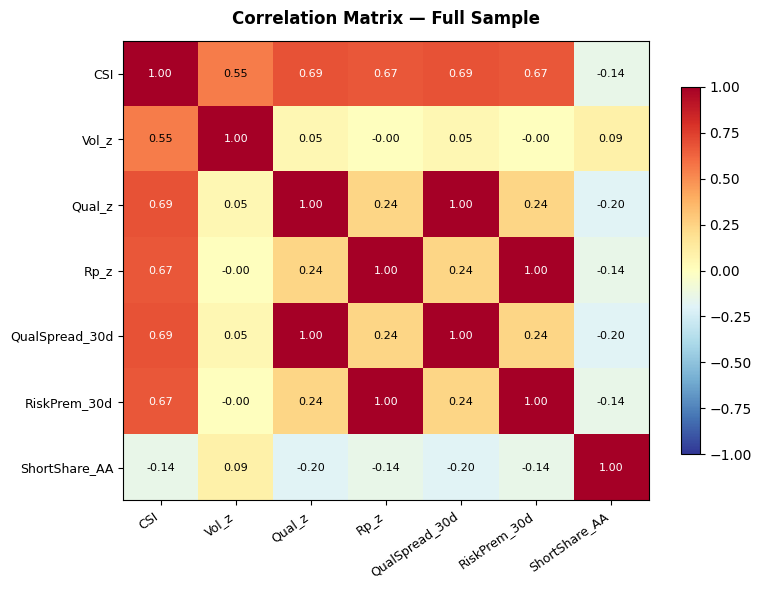

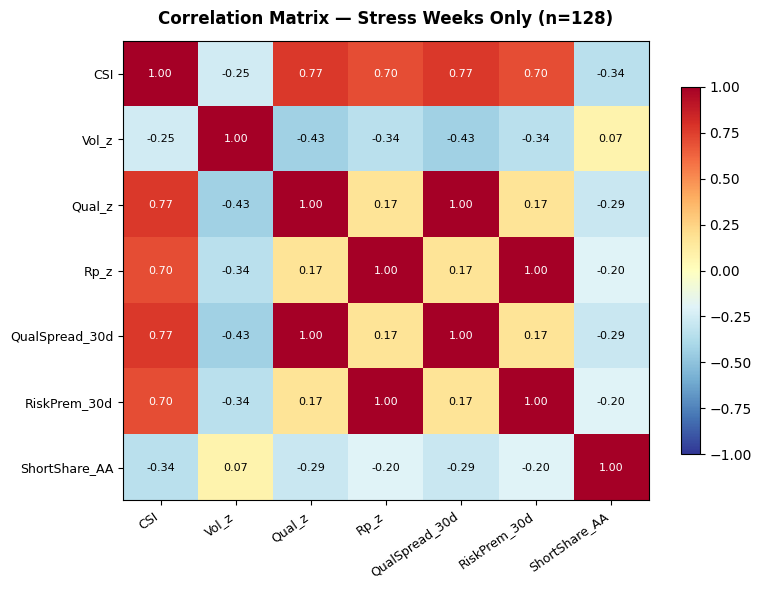


Full-sample correlations with CSI:
────────────────────────────────────────
Qual_z            0.686
QualSpread_30d    0.686
RiskPrem_30d      0.666
Rp_z              0.666
Vol_z             0.547
ShortShare_AA    -0.142


In [46]:
# CELL 7.2 — Correlation matrix

corr_vars = desc_vars[["CSI", "Vol_z", "Qual_z", "Rp_z",
                        "QualSpread_30d", "RiskPrem_30d", "ShortShare_AA"]]

corr_full   = corr_vars.corr().round(3)
corr_stress = corr_vars[stress_90].corr().round(3)

def plot_corr_heatmap(corr_df, title):
    fig, ax = plt.subplots(figsize=(8, 6))

    im = ax.imshow(corr_df.values, cmap="RdYlBu_r", vmin=-1, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax, shrink=0.8)

    n = len(corr_df)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(corr_df.columns, rotation=35, ha="right", fontsize=9)
    ax.set_yticklabels(corr_df.index, fontsize=9)

    for i in range(n):
        for j in range(n):
            val = corr_df.iloc[i, j]
            color = "white" if abs(val) > 0.6 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=8, color=color)

    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    plt.tight_layout()
    plt.show()

plot_corr_heatmap(corr_full,   "Correlation Matrix — Full Sample")
plot_corr_heatmap(corr_stress, f"Correlation Matrix — Stress Weeks Only (n={stress_90.sum()})")

print("\nFull-sample correlations with CSI:")
print("─" * 40)
print(corr_full["CSI"].drop("CSI").sort_values(ascending=False).to_string())

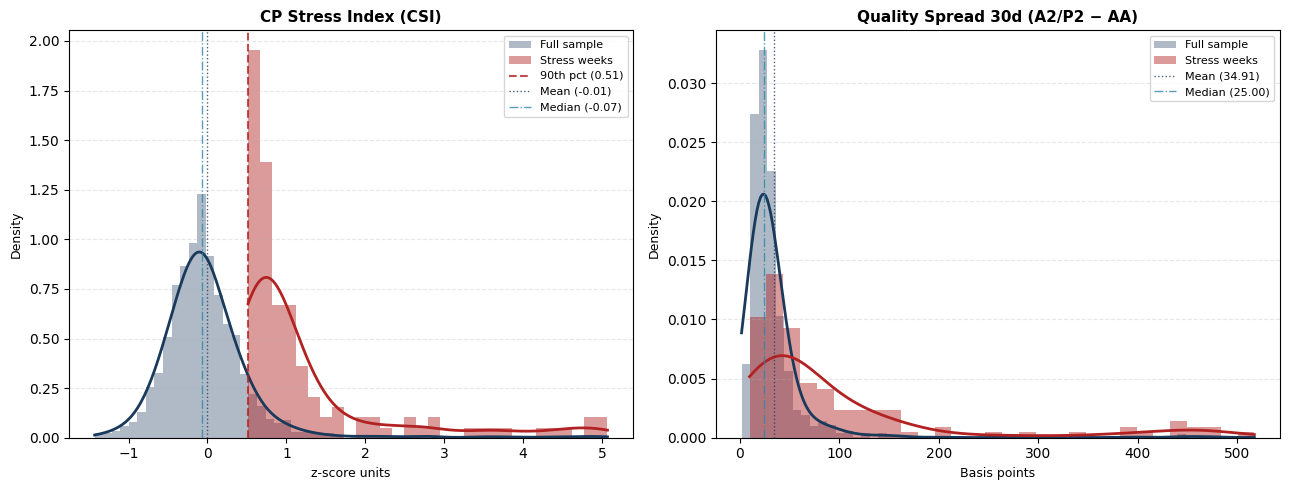

In [47]:
# CELL 7.3 — Distribution plots

from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_specs = [
    ("CSI",            "CP Stress Index (CSI)",           "z-score units"),
    ("QualSpread_30d", "Quality Spread 30d (A2/P2 − AA)", "Basis points"),
]

for ax, (var, title, xlabel) in zip(axes, plot_specs):
    data_full   = desc_vars[var].dropna()
    data_stress = desc_vars.loc[stress_90, var].dropna()

    ax.hist(data_full,   bins=60, color="#1a3a5c", alpha=0.35,
            density=True, label="Full sample")
    ax.hist(data_stress, bins=30, color="firebrick", alpha=0.45,
            density=True, label="Stress weeks")

    for data, color in [(data_full, "#1a3a5c"), (data_stress, "firebrick")]:
        if len(data) > 10:
            kde = gaussian_kde(data, bw_method=0.3)
            x   = np.linspace(data.min(), data.max(), 300)
            ax.plot(x, kde(x), color=color, lw=2)

    if var == "CSI":
        ax.axvline(threshold_90, color="firebrick", lw=1.5, linestyle="--",
                   alpha=0.8, label=f"90th pct ({threshold_90:.2f})")

    ax.axvline(data_full.mean(),   color="#1a3a5c", lw=1, linestyle=":",
               alpha=0.8, label=f"Mean ({data_full.mean():.2f})")
    ax.axvline(data_full.median(), color="#2e86ab", lw=1, linestyle="-.",
               alpha=0.8, label=f"Median ({data_full.median():.2f})")

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
# CELL 7.4 — Stress vs. non-stress comparison table

from scipy import stats as scipy_stats

comparison_vars = {
    "CSI":            "CP Stress Index",
    "QualSpread_30d": "Quality Spread 30d (bps)",
    "RiskPrem_30d":   "Risk Premium 30d (bps)",
    "COMPAPER_bn":    "NF CP Outstanding ($bn)",
    "ShortShare_AA":  "Short-Maturity Share AA (%)",
}

non_stress = ~stress_90
gfc_mask   = pd.Series((desc_vars.index >= "2008-09-24") & (desc_vars.index <= "2008-12-03"), index=desc_vars.index)
covid_mask = pd.Series((desc_vars.index >= "2020-03-18") & (desc_vars.index <= "2020-04-29"), index=desc_vars.index)

rows = []
for var, label in comparison_vars.items():
    s  = desc_vars[var].dropna()
    ns = s[non_stress.reindex(s.index, fill_value=False)]
    st = s[stress_90.reindex(s.index, fill_value=False)]
    gf = s[gfc_mask.reindex(s.index, fill_value=False)]
    cv = s[covid_mask.reindex(s.index, fill_value=False)]

    t_stat, p_val = scipy_stats.ttest_ind(st.dropna(), ns.dropna(), equal_var=False)
    sig = "***" if p_val < 0.01 else ("**" if p_val < 0.05 else ("*" if p_val < 0.10 else ""))

    rows.append({
        "Variable":        label,
        "Non-stress mean": round(ns.mean(), 2),
        "Non-stress std":  round(ns.std(),  2),
        "Stress mean":     round(st.mean(), 2),
        "Stress std":      round(st.std(),  2),
        "Diff":            round(st.mean() - ns.mean(), 2),
        "t-stat":          round(t_stat, 2),
        "Sig":             sig,
        "GFC mean":        round(gf.mean(), 2) if len(gf) else np.nan,
        "Covid mean":      round(cv.mean(), 2) if len(cv) else np.nan,
    })

comp_df = pd.DataFrame(rows).set_index("Variable")

print("=" * 90)
print("  SECTION 7.4 — STRESS vs. NON-STRESS COMPARISON")
print(f"  Non-stress: {(~stress_90).sum()} weeks  |  Stress (90th pct): {stress_90.sum()} weeks")
print("=" * 90)
print(comp_df.to_string())
print()
print("  Significance: *** p<0.01  ** p<0.05  * p<0.10  (Welch t-test)")
print("=" * 90)

comp_df.to_csv(DATA_DIR / "FR_7_4_stress_comparison.csv")
print(f"Saved: FR_7_4_stress_comparison.csv")

  SECTION 7.4 — STRESS vs. NON-STRESS COMPARISON
  Non-stress: 1252 weeks  |  Stress (90th pct): 128 weeks
                             Non-stress mean  Non-stress std  Stress mean  Stress std   Diff  t-stat  Sig  GFC mean  Covid mean
Variable                                                                                                                       
CP Stress Index                        -0.15            0.34         1.24        1.08   1.39   14.47  ***      3.72        2.78
Quality Spread 30d (bps)               27.59           17.00       100.24      120.26  72.65    6.83  ***    436.82      136.00
Risk Premium 30d (bps)                 -0.93            8.24        18.99       29.63  19.92    7.57  ***     38.18       75.57
NF CP Outstanding ($bn)               224.33           70.57       213.20       58.53 -11.14   -1.98   **    198.00      308.38
Short-Maturity Share AA (%)            70.62           14.37        61.63       19.96  -8.99   -4.89  ***     40.95       41.

## Section 8 — Robustness Checks

This section validates the two main construction choices of the CSI: the 90th percentile stress threshold and the equal-weighting scheme. A third check verifies that the Wednesday alignment procedure did not affect the stress analysis.

- **8.1** Threshold sensitivity (85th, 90th, 95th percentile)
- **8.2** Equal-weighted vs. PCA-weighted CSI
- **8.3** Forward-fill impact on rate series

### 8.1 Threshold Sensitivity

The 90th percentile threshold used to define stress episodes is a modelling choice. This check verifies that the main findings are not sensitive to it by re-running the episode registry at the 85th and 95th percentiles and comparing episode dates, counts, and peak CSI values.

In [49]:
# CELL 8.1 — Threshold sensitivity

thresholds = {
    "85th": csi.quantile(0.85),
    "90th": csi.quantile(0.90),
    "95th": csi.quantile(0.95),
}

print("=" * 70)
print("  APPENDIX A.1 — THRESHOLD SENSITIVITY")
print("=" * 70)

for label, threshold in thresholds.items():
    stress_flag = (csi >= threshold)
    episodes    = find_episodes(stress_flag, csi, components_z, min_weeks=2)
    print(f"\n  {label} percentile  (threshold = {threshold:.3f},"
          f"  stress weeks = {stress_flag.sum()},  episodes = {len(episodes)})")
    print(f"  {'#':<4} {'Start':<13} {'End':<13} {'Weeks':<7} {'Peak date':<13} {'Peak CSI'}")
    print("  " + "─" * 58)
    for i, ep in enumerate(episodes, 1):
        print(f"  {i:<4} {str(ep['start'].date()):<13} {str(ep['end'].date()):<13}"
              f"{ep['n_weeks']:<7} {str(ep['peak_date'].date()):<13} {ep['peak_csi']:.3f}")

print()
print("=" * 70)

  APPENDIX A.1 — THRESHOLD SENSITIVITY

  85th percentile  (threshold = 0.375,  stress weeks = 191,  episodes = 32)
  #    Start         End           Weeks   Peak date     Peak CSI
  ──────────────────────────────────────────────────────────
  1    2000-05-03    2000-05-17   3       2000-05-10    1.431
  2    2000-12-06    2000-12-20   3       2000-12-20    1.050
  3    2001-12-19    2001-12-26   2       2001-12-19    0.668
  4    2002-02-27    2002-03-13   3       2002-03-06    0.736
  5    2003-12-10    2004-01-14   6       2003-12-24    0.877
  6    2004-12-01    2004-12-08   2       2004-12-01    0.534
  7    2005-06-22    2005-07-13   4       2005-07-06    1.056
  8    2005-12-07    2005-12-21   3       2005-12-21    1.257
  9    2006-01-04    2006-01-18   3       2006-01-04    0.900
  10   2007-08-15    2007-09-12   5       2007-08-22    1.674
  11   2007-10-10    2007-10-17   2       2007-10-10    0.730
  12   2007-12-05    2008-01-02   5       2007-12-19    1.522
  13   2008-0

### 8.2 Equal-Weighted vs. PCA-Weighted CSI

The CSI uses equal weights across the three z-scored components. This check compares the equal-weighted index against a PCA-weighted alternative using the PC1 loadings from Section 6.5. A high correlation between the two confirms that the weighting choice is not driving the results.

  APPENDIX A.2 — EQUAL-WEIGHTED vs. PCA-WEIGHTED CSI

  PC1 loadings (normalised weights):
    vol_z       0.0849
    qual_z      0.4750
    rp_z        0.4401

  Correlation — equal-weighted vs. PCA-weighted:
    Pearson  : 0.9089
    Spearman : 0.8040


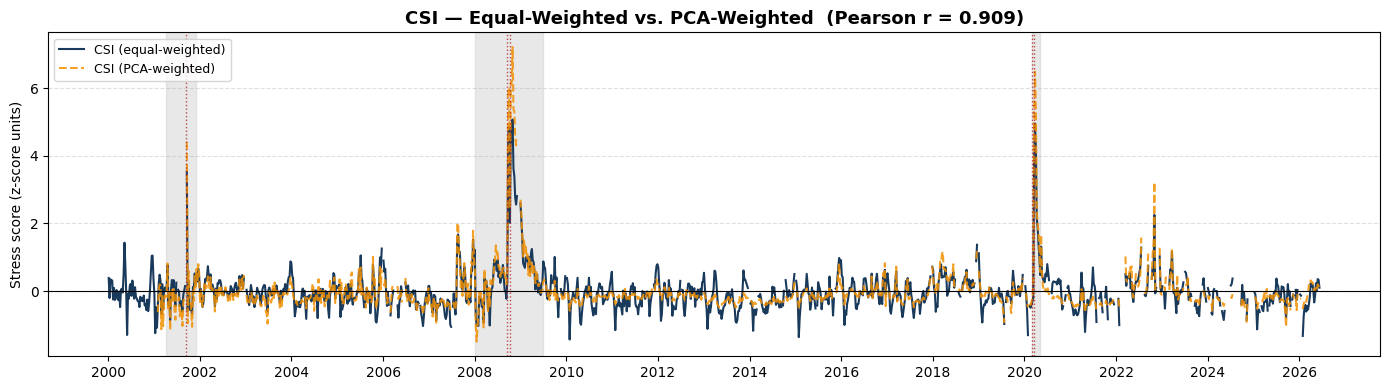

In [50]:
# CELL 8.2 — Equal-weighted vs. PCA-weighted CSI

# PCA-weighted CSI: weight each component by its PC1 loading
pc1_loadings = loadings["PC1"].abs()
pc1_weights  = pc1_loadings / pc1_loadings.sum()

csi_pca = (
    components_z[["vol_z", "qual_z", "rp_z"]]
    .mul(pc1_weights.values, axis=1)
    .sum(axis=1, skipna=False)
)
csi_pca.name = "CSI_PCA"

# Align sign — stress-up convention
if csi_pca.corr(csi) < 0:
    csi_pca = -csi_pca

corr_pearson  = csi_pca.corr(csi)
corr_spearman = csi_pca.corr(csi, method="spearman")

print("=" * 55)
print("  APPENDIX A.2 — EQUAL-WEIGHTED vs. PCA-WEIGHTED CSI")
print("=" * 55)
print(f"\n  PC1 loadings (normalised weights):")
for comp, w in pc1_weights.items():
    print(f"    {comp:<10}  {w:.4f}")
print(f"\n  Correlation — equal-weighted vs. PCA-weighted:")
print(f"    Pearson  : {corr_pearson:.4f}")
print(f"    Spearman : {corr_spearman:.4f}")
print("=" * 55)

fig, ax = plt.subplots(figsize=(14, 4))
shade_recessions(ax, usrec)

ax.plot(csi.index,     csi,     lw=1.5, color="#1a3a5c", label="CSI (equal-weighted)")
ax.plot(csi_pca.index, csi_pca, lw=1.5, color="#f18f01", label="CSI (PCA-weighted)",
        linestyle="--", alpha=0.85)
ax.axhline(0, color="black", lw=0.8)

for label, date in EVENTS.items():
    ax.axvline(pd.Timestamp(date), color="firebrick", lw=1,
               linestyle=":", alpha=0.8)

ax.set_title(f"CSI — Equal-Weighted vs. PCA-Weighted  (Pearson r = {corr_pearson:.3f})",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Stress score (z-score units)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### 8.3 Forward-Fill Impact on Rate Series

The Wednesday alignment in Section 5.1 applies a `limit=1` forward-fill to daily rate series. This check verifies that no filled weeks coincide with stress episodes — the only case where a filled value could materially affect the analysis.

In [51]:
# CELL 8.3 — Forward-fill impact on rate series

RATE_SERIES = [
    "RIFSPPNAAD01NB",   "RIFSPPNAAD07NB",   "RIFSPPNAAD30NB",
    "RIFSPPNA2P2D01NB", "RIFSPPNA2P2D07NB", "RIFSPPNA2P2D30NB",
    "RIFSPPNA2P2D60NB", "RIFSPPNA2P2D90NB",
]

print("=" * 65)
print("  DIAGNOSTIC — ffill impact on rate series")
print("=" * 65)
print(f"  {'Series':<25} {'Filled wks':<12} {'During stress':<15} {'Dates'}")
print("  " + "─" * 63)

any_concern = False

for sid in RATE_SERIES:
    try:
        raw = load_series(sid)[sid]
    except FileNotFoundError:
        print(f"  {sid:<25} [CSV not found]")
        continue

    no_fill   = raw.reindex(master.index)
    with_fill = raw.reindex(master.index).fillna(
        raw.reindex(master.index, method="ffill", limit=1)
    )

    filled_mask        = no_fill.isna() & with_fill.notna()
    n_filled           = filled_mask.sum()
    stress_and_filled  = filled_mask & (stress_90 == 1)
    n_stress           = stress_and_filled.sum()

    if n_stress > 0:
        any_concern = True
        dates = ", ".join(str(d.date()) for d in
                          stress_and_filled[stress_and_filled].index[:5])
        if stress_and_filled.sum() > 5:
            dates += f" ... (+{stress_and_filled.sum()-5} more)"
    else:
        dates = "—"

    flag = " ◀ check" if n_stress > 0 else ""
    print(f"  {sid:<25} {n_filled:<12} {n_stress:<15} {dates}{flag}")

print()
if any_concern:
    print("  ⚠  Some filled weeks coincide with stress episodes — see above.")
    print("     Verify the filled value is close to surrounding days in the raw CSV.")
else:
    print("  ✓  No filled weeks coincide with stress episodes.")
    print("     The limit=1 ffill had no impact on the stress analysis.")
print("=" * 65)

  DIAGNOSTIC — ffill impact on rate series
  Series                    Filled wks   During stress   Dates
  ───────────────────────────────────────────────────────────────
  RIFSPPNAAD01NB            1            0               —
  RIFSPPNAAD07NB            1            0               —
  RIFSPPNAAD30NB            1            0               —
  RIFSPPNA2P2D01NB          1            0               —
  RIFSPPNA2P2D07NB          1            0               —
  RIFSPPNA2P2D30NB          1            0               —
  RIFSPPNA2P2D60NB          1            0               —
  RIFSPPNA2P2D90NB          1            0               —

  ✓  No filled weeks coincide with stress episodes.
     The limit=1 ffill had no impact on the stress analysis.
